In [35]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import matplotlib.pyplot as plt
import shap

# LIME은 설치 안 되어 있을 수 있음
# !pip install lime
from lime.lime_tabular import LimeTabularExplainer
plt.rc(group='figure', figsize = (4,4), dpi = 120)

In [24]:
os.chdir('../data')

In [25]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [26]:
train.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Num ID
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,14860
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,47181
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,47182
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,47183
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,47184


In [27]:
test.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,10001,M24860,M,300.5,309.5,1451,47.8,93,No Failure
1,10002,M24861,M,301.4,311.1,1697,35.6,160,No Failure
2,10003,H39413,H,304.0,313.1,1612,33.7,100,No Failure
3,10004,L57175,L,298.6,310.5,1276,55.2,91,No Failure
4,10005,L57176,L,299.9,310.8,1400,46.2,219,No Failure


In [28]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
 10  Num ID                   10000 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


In [29]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      3000 non-null   int64  
 1   Product ID               3000 non-null   str    
 2   Type                     3000 non-null   str    
 3   Air temperature [K]      3000 non-null   float64
 4   Process temperature [K]  3000 non-null   float64
 5   Rotational speed [rpm]   3000 non-null   int64  
 6   Torque [Nm]              3000 non-null   float64
 7   Tool wear [min]          3000 non-null   int64  
 8   Failure Type             3000 non-null   str    
dtypes: float64(3), int64(3), str(3)
memory usage: 211.1 KB


In [45]:
print("train_columns : ", train.columns)
print("test_columns : ", test.columns)

train_columns :  Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type', 'Num ID'],
      dtype='str')
test_columns :  Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Failure Type'],
      dtype='str')


In [ ]:
# train = train.drop(columns = ['UDI', 'Num ID']).set_index(keys = 'Product ID')
# train.columns = ['Type', 'AirTmp', 'ProcessTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target', 'Failure Type']
# train = train.drop(columns=['Failure Type'])
# train.head() 

,Type,AirTmp,ProcessTmp,RotSpd,Torque,ToolWear,Target
Product ID,,,,,,,
M14860,M,298.1,308.6,1551,42.8,0,0
L47181,L,298.2,308.7,1408,46.3,3,0
L47182,L,298.1,308.5,1498,49.4,5,0
L47183,L,298.2,308.6,1433,39.5,7,0
L47184,L,298.2,308.7,1408,40.0,9,0


In [31]:
# 6. train / test 컬럼 차이 확인
train_cols = set(train.columns)
test_cols = set(test.columns)

print("\ntrain에만 있는 컬럼:", train_cols - test_cols)
print("test에만 있는 컬럼:", test_cols - train_cols)


train에만 있는 컬럼: {'Num ID', 'Target'}
test에만 있는 컬럼: set()


In [32]:
print("train shape :", train.shape)
print("test shape  :", test.shape)

train shape : (10000, 11)
test shape  : (3000, 9)


In [33]:
train.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type',
 'Num ID']

In [34]:
print(train["Target"].value_counts())

print("\n비율")
print(train["Target"].value_counts(normalize=True))

Target
0    9661
1     339
Name: count, dtype: int64

비율
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64


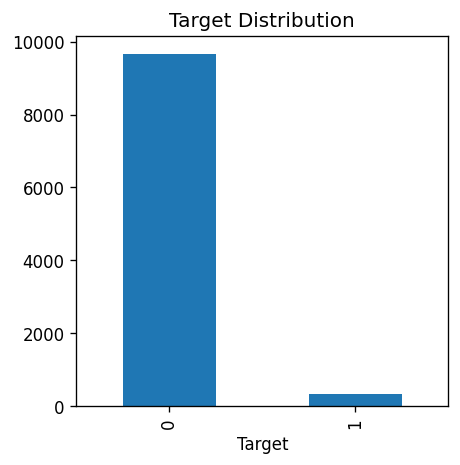

In [36]:
train["Target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

In [37]:
print(train["Failure Type"].value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [38]:
pd.crosstab(train["Failure Type"], train["Target"])

Target,0,1
Failure Type,,
Heat Dissipation Failure,0,112
No Failure,9643,9
Overstrain Failure,0,78
Power Failure,0,95
Random Failures,18,0
Tool Wear Failure,0,45


In [39]:
train["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

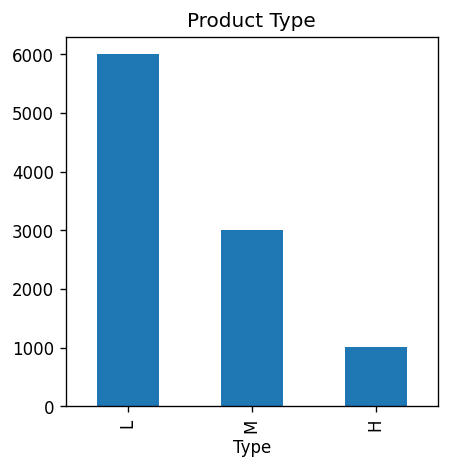

In [40]:
train["Type"].value_counts().plot(kind="bar")
plt.title("Product Type")
plt.show()

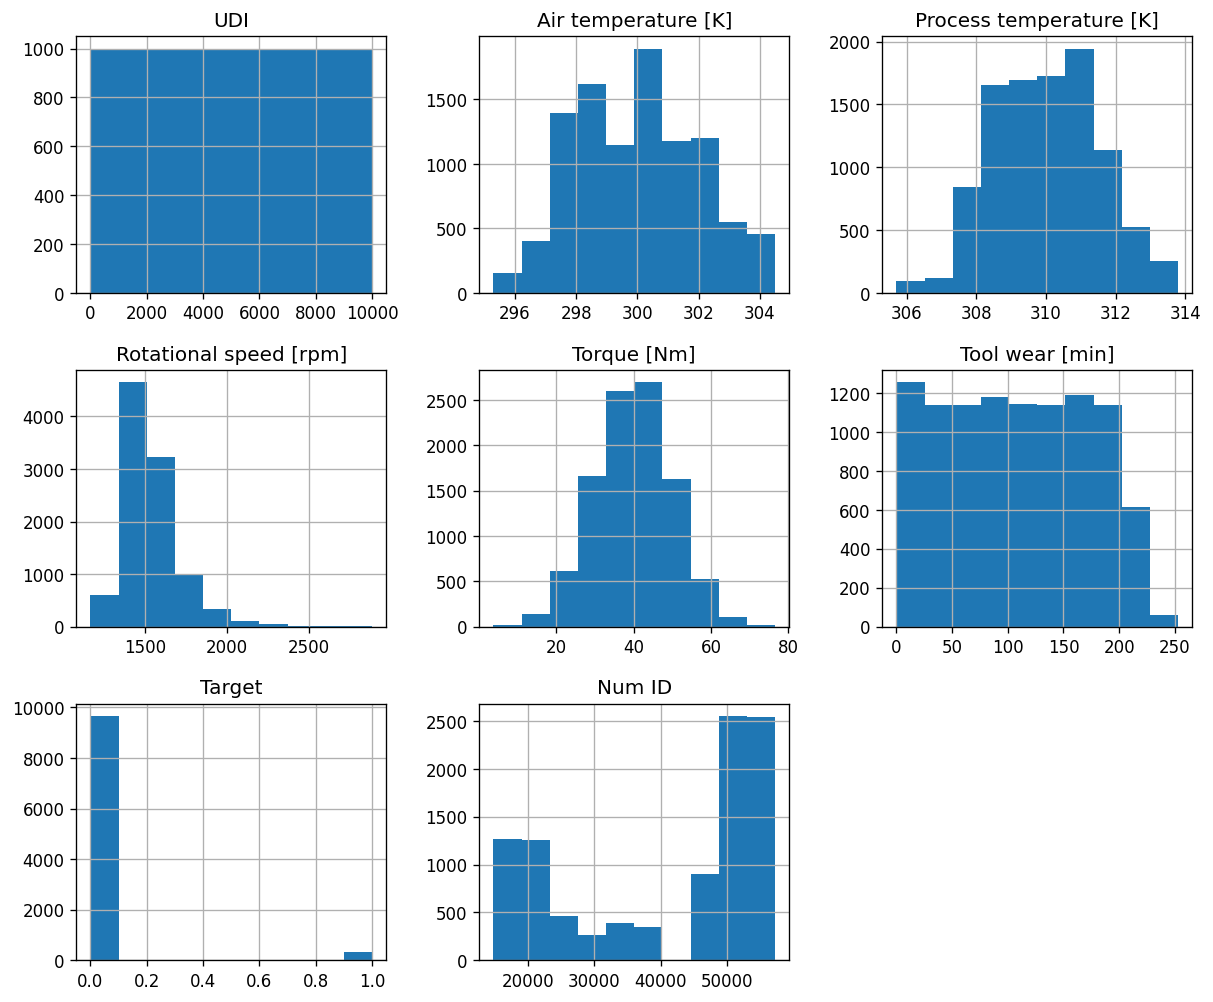

In [41]:
train.hist(figsize=(12,10))
plt.show()

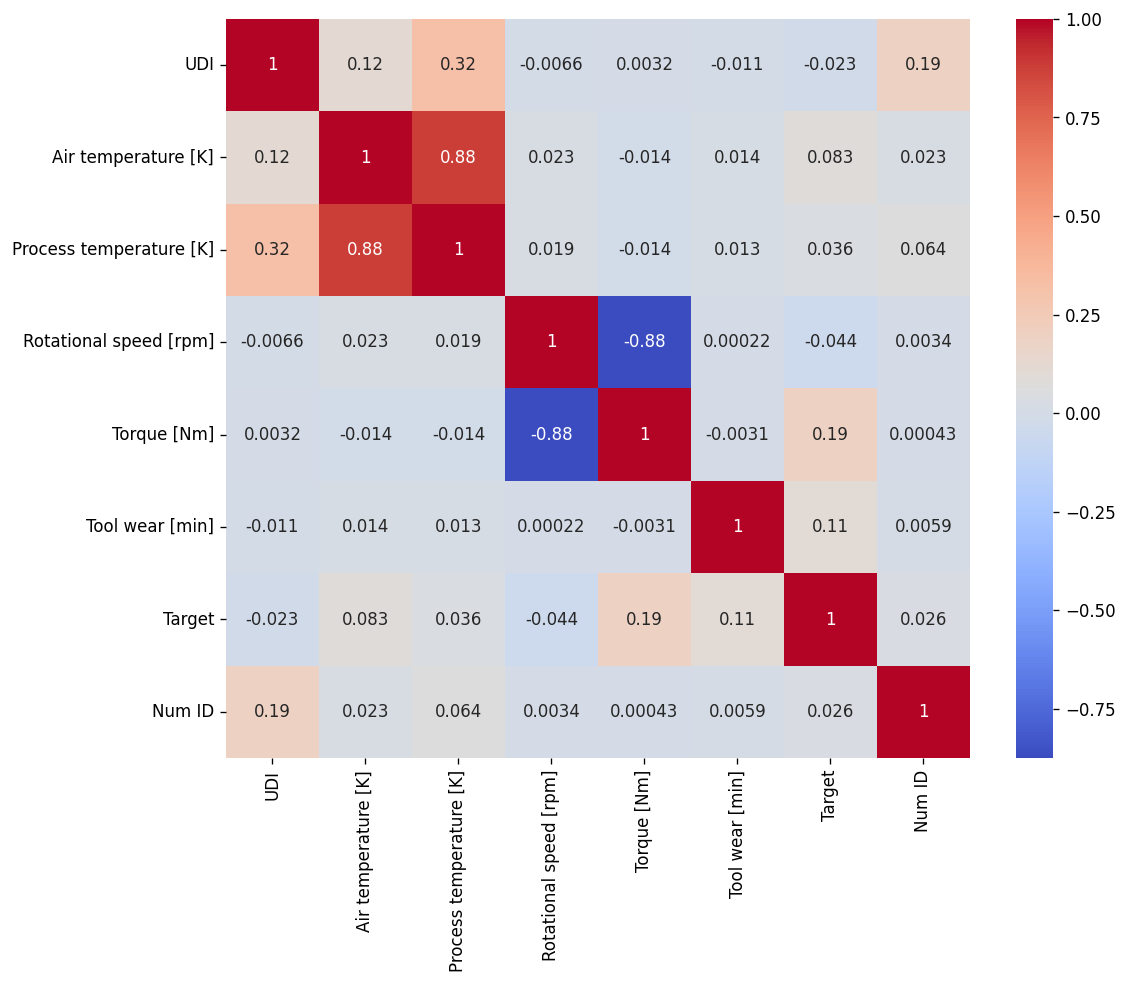

In [42]:
import seaborn as sns

corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [43]:
train["Product ID"].head(10)

0    M14860
1    L47181
2    L47182
3    L47183
4    L47184
5    M14865
6    L47186
7    L47187
8    M14868
9    M14869
Name: Product ID, dtype: str

In [ ]:
from sklearn.preprocessing import LabelEncoder

drop_cols = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_clean = train.drop(columns=drop_cols, errors="ignore")
test_clean = test.drop(columns=drop_cols, errors="ignore")
# 컬럼 무시하고 진행

le = LabelEncoder()

train_clean["Type"] = le.fit_transform(train_clean["Type"])
test_clean["Type"] = le.transform(test_clean["Type"])

X = train_clean.drop("Target", axis=1)
y = train_clean["Target"]

test_id = test["UDI"]
X_test = test_clean

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (10000, 6)
X_test shape: (3000, 6)


In [48]:
# 1. 온도 차이
X["temp_diff"] = X["Process temperature [K]"] - X["Air temperature [K]"]
X_test["temp_diff"] = X_test["Process temperature [K]"] - X_test["Air temperature [K]"]

# 2. 회전수 * 토크
X["power_like"] = X["Rotational speed [rpm]"] * X["Torque [Nm]"]
X_test["power_like"] = X_test["Rotational speed [rpm]"] * X_test["Torque [Nm]"]

# 3. 마모 * 토크
X["wear_torque"] = X["Tool wear [min]"] * X["Torque [Nm]"]
X_test["wear_torque"] = X_test["Tool wear [min]"] * X_test["Torque [Nm]"]

# 4. 회전수 / 마모
X["rpm_per_wear"] = X["Rotational speed [rpm]"] / (X["Tool wear [min]"] + 1)
X_test["rpm_per_wear"] = X_test["Rotational speed [rpm]"] / (X_test["Tool wear [min]"] + 1)

# 5. 토크 / 회전수
X["torque_per_rpm"] = X["Torque [Nm]"] / (X["Rotational speed [rpm]"] + 1)
X_test["torque_per_rpm"] = X_test["Torque [Nm]"] / (X_test["Rotational speed [rpm]"] + 1)

# 6. 온도 차이 * 마모
X["temp_wear"] = X["temp_diff"] * X["Tool wear [min]"]
X_test["temp_wear"] = X_test["temp_diff"] * X_test["Tool wear [min]"]

print("X shape after FE:", X.shape)
print("X_test shape after FE:", X_test.shape)

print("\n새로 추가된 컬럼:")
print(X.columns.tolist())

X shape after FE: (10000, 12)
X_test shape after FE: (3000, 12)

새로 추가된 컬럼:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power_like', 'wear_torque', 'rpm_per_wear', 'torque_per_rpm', 'temp_wear']


In [49]:
X.columns.tolist()

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'temp_diff',
 'power_like',
 'wear_torque',
 'rpm_per_wear',
 'torque_per_rpm',
 'temp_wear']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (8000, 12)
X_valid: (2000, 12)


In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
y_pred = model.predict(X_valid)
y_prob = model.predict_proba(X_valid)[:,1]

In [53]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc = roc_auc_score(y_valid, y_prob)
pr = average_precision_score(y_valid, y_prob)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.9770429911094872
PR-AUC: 0.8501488443803404


In [54]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

torque_per_rpm             0.164668
Rotational speed [rpm]     0.146254
power_like                 0.133544
Torque [Nm]                0.133134
temp_diff                  0.078564
Tool wear [min]            0.078416
wear_torque                0.078187
rpm_per_wear               0.069307
Air temperature [K]        0.045023
temp_wear                  0.044175
Process temperature [K]    0.023086
Type                       0.005644
dtype: float64


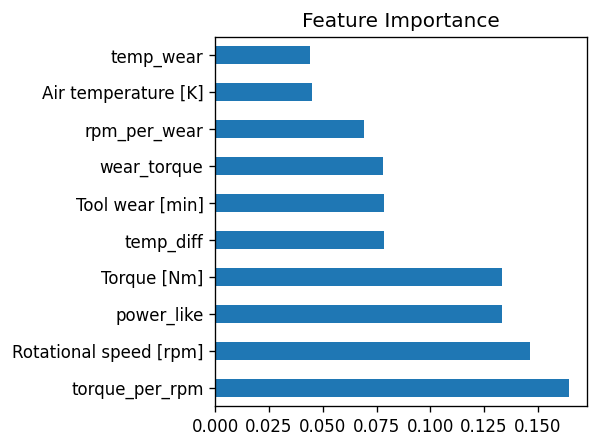

In [55]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [56]:
test_prob = model.predict_proba(X_test)[:,1]

In [57]:
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_prob
})

submission.to_csv("test12.csv", index=False)

print(submission.head())

     UDI    Target
0  10001  0.000000
1  10002  0.000000
2  10003  0.000000
3  10004  0.003333
4  10005  0.230000


### ----------------

In [68]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, valid_idx in skf.split(X, y):

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_valid)[:,1]

    score = roc_auc_score(y_valid, y_prob)

    scores.append(score)

print("Fold scores:", scores)
print("Mean ROC-AUC:", np.mean(scores))

Fold scores: [0.9728015380932893, 0.9799126172208015, 0.9728793691389599, 0.9749992388259652, 0.9694236390208257]
Mean ROC-AUC: 0.9740032804599684


In [69]:
model.fit(X, y)

test_prob = model.predict_proba(X_test)[:,1]

In [70]:
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_prob
})

submission.to_csv("test123.csv", index=False)

### ===================

In [71]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# =========================
# 1. 데이터 로드
# =========================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)

# =========================
# 2. 전처리
# =========================
# 제거 컬럼
drop_cols = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_clean = train.drop(columns=drop_cols, errors="ignore").copy()
test_clean = test.drop(columns=drop_cols, errors="ignore").copy()

# Type 인코딩
le = LabelEncoder()
train_clean["Type"] = le.fit_transform(train_clean["Type"])
test_clean["Type"] = le.transform(test_clean["Type"])

# X, y 분리
X = train_clean.drop("Target", axis=1).copy()
y = train_clean["Target"].copy()
X_test = test_clean.copy()
test_id = test["UDI"].copy()

# =========================
# 3. Feature Engineering
# =========================
def add_features(df):
    df = df.copy()
    
    # 기존 파생변수
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]

    # 추가 파생변수
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["torque_temp"] = df["Torque [Nm]"] * df["Process temperature [K]"]
    df["rpm_temp"] = df["Rotational speed [rpm]"] * df["temp_diff"]
    df["wear_per_tempdiff"] = df["Tool wear [min]"] / (df["temp_diff"].abs() + 1)
    df["torque_wear_ratio"] = df["Torque [Nm]"] / (df["Tool wear [min]"] + 1)

    # 로그 변환
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])
    df["wear_log"] = np.log1p(df["Tool wear [min]"])

    return df

X = add_features(X)
X_test = add_features(X_test)

print("X shape after FE:", X.shape)
print("X_test shape after FE:", X_test.shape)

# =========================
# 4. KFold 설정
# =========================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# OOF / Test 저장용
oof_rf = np.zeros(len(X))
oof_et = np.zeros(len(X))

test_pred_rf = np.zeros(len(X_test))
test_pred_et = np.zeros(len(X_test))

rf_scores = []
et_scores = []

# =========================
# 5. RandomForest KFold
# =========================
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    rf_model = RandomForestClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    valid_prob = rf_model.predict_proba(X_valid)[:, 1]
    test_prob = rf_model.predict_proba(X_test)[:, 1]

    oof_rf[valid_idx] = valid_prob
    test_pred_rf += test_prob / skf.n_splits

    fold_auc = roc_auc_score(y_valid, valid_prob)
    rf_scores.append(fold_auc)

    print(f"[RF] Fold {fold} AUC: {fold_auc:.6f}")

print("\n[RF] Fold scores:", rf_scores)
print("[RF] Mean AUC:", np.mean(rf_scores))
print("[RF] OOF ROC-AUC:", roc_auc_score(y, oof_rf))
print("[RF] OOF PR-AUC :", average_precision_score(y, oof_rf))


# =========================
# 6. ExtraTrees KFold
# =========================
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    et_model = ExtraTreesClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    et_model.fit(X_train, y_train)

    valid_prob = et_model.predict_proba(X_valid)[:, 1]
    test_prob = et_model.predict_proba(X_test)[:, 1]

    oof_et[valid_idx] = valid_prob
    test_pred_et += test_prob / skf.n_splits

    fold_auc = roc_auc_score(y_valid, valid_prob)
    et_scores.append(fold_auc)

    print(f"[ET] Fold {fold} AUC: {fold_auc:.6f}")

print("\n[ET] Fold scores:", et_scores)
print("[ET] Mean AUC:", np.mean(et_scores))
print("[ET] OOF ROC-AUC:", roc_auc_score(y, oof_et))
print("[ET] OOF PR-AUC :", average_precision_score(y, oof_et))


# =========================
# 7. 앙상블
# =========================
# RF + ET 평균
oof_ens = (oof_rf + oof_et) / 2
test_pred_ens = (test_pred_rf + test_pred_et) / 2

print("\n[ENSEMBLE] OOF ROC-AUC:", roc_auc_score(y, oof_ens))
print("[ENSEMBLE] OOF PR-AUC :", average_precision_score(y, oof_ens))

# =========================
# 8. 중요도 확인 (ExtraTrees 기준)
# =========================
# 마지막 fold 모델이 아니라 전체 데이터로 한 번 더 학습해서 importance 확인
final_et = ExtraTreesClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_et.fit(X, y)

importance = pd.Series(final_et.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 15 Feature Importance")
print(importance.head(15))

# =========================
# 9. 제출 파일 생성
# =========================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_pred_ens
})

submission.to_csv("tree1234.csv", index=False)
print("\nsubmission_ensemble.csv 저장 완료")
print(submission.head())

train shape: (10000, 11)
test shape: (3000, 9)
X shape after FE: (10000, 20)
X_test shape after FE: (3000, 20)
[RF] Fold 1 AUC: 0.980554
[RF] Fold 2 AUC: 0.984993
[RF] Fold 3 AUC: 0.986660
[RF] Fold 4 AUC: 0.971776
[RF] Fold 5 AUC: 0.977013

[RF] Fold scores: [0.9805537753549891, 0.9849934539033003, 0.9866604250395811, 0.9717756667884546, 0.9770125441480941]
[RF] Mean AUC: 0.9801991730468839
[RF] OOF ROC-AUC: 0.9799658267785296
[RF] OOF PR-AUC : 0.8804724308391579
[ET] Fold 1 AUC: 0.972906
[ET] Fold 2 AUC: 0.975224
[ET] Fold 3 AUC: 0.978619
[ET] Fold 4 AUC: 0.973469
[ET] Fold 5 AUC: 0.970710

[ET] Fold scores: [0.9729057763433222, 0.9752237851662403, 0.9786186213615881, 0.9734692790159543, 0.9707100231396906]
[ET] Mean AUC: 0.9741854970053592
[ET] OOF ROC-AUC: 0.9740361988214634
[ET] OOF PR-AUC : 0.8363740975399215

[ENSEMBLE] OOF ROC-AUC: 0.9780420563900901
[ENSEMBLE] OOF PR-AUC : 0.8688751608953544

Top 15 Feature Importance
torque_per_rpm            0.079033
Torque [Nm]             

### 컬럼 줄이기

In [72]:
top_n = 12
selected_features = importance.head(top_n).index.tolist()

print("선택된 feature:")
print(selected_features)

선택된 feature:
['torque_per_rpm', 'Torque [Nm]', 'torque_temp', 'rpm_temp', 'power_like', 'rpm_log', 'wear_torque', 'torque_log', 'Rotational speed [rpm]', 'Tool wear [min]', 'temp_ratio', 'temp_diff']


In [73]:
X_sel = X[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

print("X_sel shape:", X_sel.shape)
print("X_test_sel shape:", X_test_sel.shape)

X_sel shape: (10000, 12)
X_test_sel shape: (3000, 12)


In [74]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_rf_sel = np.zeros(len(X_sel))
test_pred_rf_sel = np.zeros(len(X_test_sel))
rf_sel_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_sel, y), 1):
    X_train, X_valid = X_sel.iloc[train_idx], X_sel.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    rf_model = RandomForestClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    valid_prob = rf_model.predict_proba(X_valid)[:, 1]
    test_prob = rf_model.predict_proba(X_test_sel)[:, 1]

    oof_rf_sel[valid_idx] = valid_prob
    test_pred_rf_sel += test_prob / skf.n_splits

    fold_auc = roc_auc_score(y_valid, valid_prob)
    rf_sel_scores.append(fold_auc)

    print(f"[Selected RF] Fold {fold} AUC: {fold_auc:.6f}")

print("\n[Selected RF] Fold scores:", rf_sel_scores)
print("[Selected RF] Mean AUC:", np.mean(rf_sel_scores))
print("[Selected RF] OOF ROC-AUC:", roc_auc_score(y, oof_rf_sel))
print("[Selected RF] OOF PR-AUC :", average_precision_score(y, oof_rf_sel))

[Selected RF] Fold 1 AUC: 0.967122
[Selected RF] Fold 2 AUC: 0.981188
[Selected RF] Fold 3 AUC: 0.979304
[Selected RF] Fold 4 AUC: 0.973138
[Selected RF] Fold 5 AUC: 0.982622

[Selected RF] Fold scores: [0.9671224838044645, 0.9811875837291437, 0.9793036779929363, 0.9731381683108025, 0.9826223967848009]
[Selected RF] Mean AUC: 0.9766748621244294
[Selected RF] OOF ROC-AUC: 0.9762906482561183
[Selected RF] OOF PR-AUC : 0.8731867582676819


In [76]:
submission_fs = pd.DataFrame({
    "UDI": test_id,
    "Target": test_pred_rf_sel
})

submission_fs.to_csv("fest12.csv", index=False)

print(submission_fs.head())
print("submission_feature_selection.csv 저장 완료")

     UDI    Target
0  10001  0.005882
1  10002  0.000214
2  10003  0.000026
3  10004  0.001926
4  10005  0.345505
submission_feature_selection.csv 저장 완료


In [75]:
for top_n in [8, 10, 12, 15]:
    selected_features = importance.head(top_n).index.tolist()
    print(top_n, selected_features)

8 ['torque_per_rpm', 'Torque [Nm]', 'torque_temp', 'rpm_temp', 'power_like', 'rpm_log', 'wear_torque', 'torque_log']
10 ['torque_per_rpm', 'Torque [Nm]', 'torque_temp', 'rpm_temp', 'power_like', 'rpm_log', 'wear_torque', 'torque_log', 'Rotational speed [rpm]', 'Tool wear [min]']
12 ['torque_per_rpm', 'Torque [Nm]', 'torque_temp', 'rpm_temp', 'power_like', 'rpm_log', 'wear_torque', 'torque_log', 'Rotational speed [rpm]', 'Tool wear [min]', 'temp_ratio', 'temp_diff']
15 ['torque_per_rpm', 'Torque [Nm]', 'torque_temp', 'rpm_temp', 'power_like', 'rpm_log', 'wear_torque', 'torque_log', 'Rotational speed [rpm]', 'Tool wear [min]', 'temp_ratio', 'temp_diff', 'wear_per_tempdiff', 'temp_wear', 'wear_log']


### ================

In [77]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

# =========================================================
# 2. 전처리
# =========================================================
drop_cols = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_clean = train.drop(columns=drop_cols, errors="ignore").copy()
test_clean = test.drop(columns=drop_cols, errors="ignore").copy()

# Type 인코딩
le = LabelEncoder()
train_clean["Type"] = le.fit_transform(train_clean["Type"])
test_clean["Type"] = le.transform(test_clean["Type"])

# X, y, test_id 분리
X = train_clean.drop("Target", axis=1).copy()
y = train_clean["Target"].copy()
X_test = test_clean.copy()
test_id = test["UDI"].copy()

print("기본 X shape:", X.shape)
print("기본 X_test shape:", X_test.shape)

# =========================================================
# 3. Feature Engineering
# =========================================================
def add_features(df):
    df = df.copy()

    # 기존 파생변수
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]

    # 추가 파생변수
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["torque_temp"] = df["Torque [Nm]"] * df["Process temperature [K]"]
    df["rpm_temp"] = df["Rotational speed [rpm]"] * df["temp_diff"]
    df["wear_per_tempdiff"] = df["Tool wear [min]"] / (df["temp_diff"].abs() + 1)
    df["torque_wear_ratio"] = df["Torque [Nm]"] / (df["Tool wear [min]"] + 1)

    # 로그 변환
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])
    df["wear_log"] = np.log1p(df["Tool wear [min]"])

    # 추가로 성능 개선용 상호작용 변수
    df["tempdiff_rpm"] = df["temp_diff"] * df["Rotational speed [rpm]"]
    df["tempdiff_torque"] = df["temp_diff"] * df["Torque [Nm]"]
    df["wear_rpm_ratio"] = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)
    df["process_air_sum"] = df["Process temperature [K]"] + df["Air temperature [K]"]
    df["torque_square"] = df["Torque [Nm]"] ** 2
    df["rpm_square"] = df["Rotational speed [rpm]"] ** 2

    return df

X = add_features(X)
X_test = add_features(X_test)

print("FE 후 X shape:", X.shape)
print("FE 후 X_test shape:", X_test.shape)

# =========================================================
# 4. 전체 feature importance 산출용 모델 학습
# =========================================================
base_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=14,
    min_samples_leaf=1,
    min_samples_split=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

base_model.fit(X, y)

importance = pd.Series(
    base_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n[전체 Feature Importance Top 20]")
print(importance.head(20))

# =========================================================
# 5. top_n 자동 탐색
# =========================================================
candidate_top_n = [8, 10, 12, 14, 16, 18, 20]
results = []

print("\n===== top_n 탐색 시작 =====")

for top_n in candidate_top_n:
    selected_features = importance.head(top_n).index.tolist()

    X_sel = X[selected_features].copy()

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_pred = np.zeros(len(X_sel))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_sel, y), 1):
        X_train, X_valid = X_sel.iloc[train_idx], X_sel.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = RandomForestClassifier(
            n_estimators=1200,
            max_depth=14,
            min_samples_leaf=1,
            min_samples_split=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        valid_prob = model.predict_proba(X_valid)[:, 1]

        oof_pred[valid_idx] = valid_prob
        fold_auc = roc_auc_score(y_valid, valid_prob)
        fold_scores.append(fold_auc)

    mean_auc = np.mean(fold_scores)
    oof_auc = roc_auc_score(y, oof_pred)
    oof_pr = average_precision_score(y, oof_pred)

    results.append({
        "top_n": top_n,
        "mean_fold_auc": mean_auc,
        "oof_auc": oof_auc,
        "oof_pr_auc": oof_pr,
        "features": selected_features
    })

    print(f"top_n={top_n} | Mean AUC={mean_auc:.6f} | OOF AUC={oof_auc:.6f} | OOF PR-AUC={oof_pr:.6f}")

# 결과 정리
results_df = pd.DataFrame(results).sort_values(by="oof_auc", ascending=False).reset_index(drop=True)

print("\n===== top_n 탐색 결과 =====")
print(results_df[["top_n", "mean_fold_auc", "oof_auc", "oof_pr_auc"]])

# =========================================================
# 6. 최고 성능 top_n 선택
# =========================================================
best_top_n = results_df.loc[0, "top_n"]
best_features = results_df.loc[0, "features"]

print("\n최적 top_n:", best_top_n)
print("선택된 feature:")
for i, f in enumerate(best_features, 1):
    print(f"{i}. {f}")

X_best = X[best_features].copy()
X_test_best = X_test[best_features].copy()

# =========================================================
# 7. 최적 feature로 다시 KFold 학습 + test 평균 예측
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_best = np.zeros(len(X_best))
test_pred_best = np.zeros(len(X_test_best))
best_fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_best, y), 1):
    X_train, X_valid = X_best.iloc[train_idx], X_best.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = RandomForestClassifier(
        n_estimators=1500,
        max_depth=14,
        min_samples_leaf=1,
        min_samples_split=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    valid_prob = model.predict_proba(X_valid)[:, 1]
    test_prob = model.predict_proba(X_test_best)[:, 1]

    oof_best[valid_idx] = valid_prob
    test_pred_best += test_prob / skf.n_splits

    fold_auc = roc_auc_score(y_valid, valid_prob)
    best_fold_scores.append(fold_auc)

    print(f"[BEST RF] Fold {fold} AUC: {fold_auc:.6f}")

print("\n[BEST RF] Fold scores:", best_fold_scores)
print("[BEST RF] Mean AUC:", np.mean(best_fold_scores))
print("[BEST RF] OOF ROC-AUC:", roc_auc_score(y, oof_best))
print("[BEST RF] OOF PR-AUC :", average_precision_score(y, oof_best))

# =========================================================
# 8. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_pred_best
})

submission.to_csv("kfold12.csv", index=False)

print("\nsubmission_best_rf_feature_selection.csv 저장 완료")
print(submission.head())

# =========================================================
# 9. 선택 feature importance 최종 확인
# =========================================================
final_model = RandomForestClassifier(
    n_estimators=1500,
    max_depth=14,
    min_samples_leaf=1,
    min_samples_split=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_best, y)

final_importance = pd.Series(
    final_model.feature_importances_,
    index=X_best.columns
).sort_values(ascending=False)

print("\n[최종 선택 feature importance]")
print(final_importance)

train shape: (10000, 11)
test shape : (3000, 9)
기본 X shape: (10000, 6)
기본 X_test shape: (3000, 6)
FE 후 X shape: (10000, 26)
FE 후 X_test shape: (3000, 26)

[전체 Feature Importance Top 20]
torque_per_rpm            0.073834
rpm_log                   0.073580
power_like                0.069355
torque_temp               0.066821
rpm_square                0.063805
Rotational speed [rpm]    0.063080
Torque [Nm]               0.056671
torque_log                0.052893
Tool wear [min]           0.050691
wear_log                  0.049511
torque_square             0.048909
rpm_temp                  0.040913
tempdiff_rpm              0.040736
wear_rpm_ratio            0.035931
wear_torque               0.035271
rpm_per_wear              0.030068
wear_per_tempdiff         0.023635
temp_ratio                0.022579
temp_diff                 0.018819
torque_wear_ratio         0.018797
dtype: float64

===== top_n 탐색 시작 =====
top_n=8 | Mean AUC=0.849381 | OOF AUC=0.850065 | OOF PR-AUC=0.412426
top_n

### ================ 999

In [79]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

# =========================================================
# 2. 케이스 정의
# =========================================================
# Case B: Target=1 & Failure Type='No Failure'
# -> 실제 센서 기반 고장 신호로 보고 보조 feature 생성
#
# Case C: Failure Type='Random Failures'
# -> 노이즈로 판단, train에서 제거
# -> test에서는 Target=0으로 고정

case_b_mask = (train["Target"] == 1) & (train["Failure Type"] == "No Failure")
case_c_train_mask = (train["Failure Type"] == "Random Failures")
case_c_test_mask = (test["Failure Type"] == "Random Failures")

print("Case B count:", case_b_mask.sum())
print("Case C train count:", case_c_train_mask.sum())
print("Case C test count :", case_c_test_mask.sum())

# train에서 Case C 제거
train = train.loc[~case_c_train_mask].reset_index(drop=True)

print("train shape after removing Case C:", train.shape)

# =========================================================
# 3. Failure Type 가공
# =========================================================
# Failure Type 활용
# - 원문 category encoding
# - 고장 유형 여부 binary
# - No Failure 여부 binary
# - Case B 여부 binary

failure_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

train["Failure_Type_Enc"] = train["Failure Type"].map(failure_map)
test["Failure_Type_Enc"] = test["Failure Type"].map(failure_map)

train["failure_flag"] = (train["Failure Type"] != "No Failure").astype(int)
test["failure_flag"] = (test["Failure Type"] != "No Failure").astype(int)

train["no_failure_flag"] = (train["Failure Type"] == "No Failure").astype(int)
test["no_failure_flag"] = (test["Failure Type"] == "No Failure").astype(int)

# Case B flag
train["case_b_flag"] = ((train["Target"] == 1) & (train["Failure Type"] == "No Failure")).astype(int)

# test는 정답이 없으므로 직접 판단 불가
# 대신 No Failure인 경우 0으로 두고, 나머지 알려진 failure type은 0으로 둠
test["case_b_flag"] = 0

# =========================================================
# 4. 전처리
# =========================================================
# Product ID에서 prefix 추출
train["Product_Prefix"] = train["Product ID"].str[0]
test["Product_Prefix"] = test["Product ID"].str[0]

# Type / Product_Prefix 인코딩
type_le = LabelEncoder()
prefix_le = LabelEncoder()

train["Type"] = type_le.fit_transform(train["Type"])
test["Type"] = type_le.transform(test["Type"])

train["Product_Prefix"] = prefix_le.fit_transform(train["Product_Prefix"])
test["Product_Prefix"] = prefix_le.transform(test["Product_Prefix"])

# Num ID는 test에 없으니 Product ID의 숫자 부분을 직접 생성
def extract_num_id(series):
    return series.str.extract(r'(\d+)').astype(int)[0]

train["Product_Num"] = extract_num_id(train["Product ID"])
test["Product_Num"] = extract_num_id(test["Product ID"])

# 보존할 test id
test_id = test["UDI"].copy()

# =========================================================
# 5. Feature Engineering
# =========================================================
def add_features(df):
    df = df.copy()

    # 기본 파생
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["temp_sum"] = df["Process temperature [K]"] + df["Air temperature [K]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)

    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]

    # 상관관계 높은 feature 조합
    df["torque_temp"] = df["Torque [Nm]"] * df["Process temperature [K]"]
    df["rpm_tempdiff"] = df["Rotational speed [rpm]"] * df["temp_diff"]
    df["tempdiff_torque"] = df["temp_diff"] * df["Torque [Nm]"]
    df["wear_temp_ratio"] = df["Tool wear [min]"] / (df["temp_diff"].abs() + 1)
    df["temp_wear_ratio"] = df["temp_diff"] / (df["Tool wear [min]"] + 1)

    # 제곱 / 로그
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])
    df["wear_log"] = np.log1p(df["Tool wear [min]"])

    df["rpm_square"] = df["Rotational speed [rpm]"] ** 2
    df["torque_square"] = df["Torque [Nm]"] ** 2

    # Failure Type 활용 파생
    df["failure_torque"] = df["failure_flag"] * df["Torque [Nm]"]
    df["failure_rpm"] = df["failure_flag"] * df["Rotational speed [rpm]"]
    df["failure_wear"] = df["failure_flag"] * df["Tool wear [min]"]
    df["failure_tempdiff"] = df["failure_flag"] * df["temp_diff"]

    df["caseb_torque"] = df["case_b_flag"] * df["Torque [Nm]"]
    df["caseb_rpm"] = df["case_b_flag"] * df["Rotational speed [rpm]"]
    df["caseb_tempdiff"] = df["case_b_flag"] * df["temp_diff"]

    return df

train = add_features(train)
test = add_features(test)

# =========================================================
# 6. 학습용 컬럼 정리
# =========================================================
drop_cols = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]

X = train.drop(columns=drop_cols, errors="ignore").copy()
y = train["Target"].copy()

X_test = test.drop(columns=["UDI", "Product ID", "Failure Type", "Num ID"], errors="ignore").copy()

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

# 컬럼 맞춤
X_test = X_test[X.columns]

# =========================================================
# 7. 5개 모델 정의
# =========================================================
models = {
    "rf": RandomForestClassifier(
        n_estimators=700,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "et": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "lr": LogisticRegression(
        C=0.5,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ),
    "gnb": GaussianNB(),
    "knn": KNeighborsClassifier(
        n_neighbors=25,
        weights="distance",
        metric="minkowski"
    )
}

# =========================================================
# 8. Stratified K-Fold 학습
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = {name: np.zeros(len(X)) for name in models.keys()}
test_preds = {name: np.zeros(len(X_test)) for name in models.keys()}
cv_scores = {name: [] for name in models.keys()}

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    print(f"\n========== Fold {fold} ==========")

    for name, model in models.items():
        model.fit(X_train, y_train)

        valid_prob = model.predict_proba(X_valid)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        oof_preds[name][valid_idx] = valid_prob
        test_preds[name] += test_prob / skf.n_splits

        fold_auc = roc_auc_score(y_valid, valid_prob)
        cv_scores[name].append(fold_auc)

        print(f"[{name}] Fold {fold} AUC: {fold_auc:.6f}")

# =========================================================
# 9. 모델별 성능 확인
# =========================================================
print("\n========== Model CV Summary ==========")
for name in models.keys():
    oof_auc = roc_auc_score(y, oof_preds[name])
    oof_pr = average_precision_score(y, oof_preds[name])
    mean_auc = np.mean(cv_scores[name])

    print(f"{name} | Mean Fold AUC: {mean_auc:.6f} | OOF AUC: {oof_auc:.6f} | OOF PR-AUC: {oof_pr:.6f}")

# =========================================================
# 10. 앙상블
# =========================================================
# 보수적 가중치
# 트리 모델 비중 높게, 나머지는 보조
ensemble_weights = {
    "rf": 0.28,
    "et": 0.24,
    "lr": 0.20,
    "gnb": 0.14,
    "knn": 0.14
}

oof_ensemble = np.zeros(len(X))
test_ensemble = np.zeros(len(X_test))

for name, weight in ensemble_weights.items():
    oof_ensemble += oof_preds[name] * weight
    test_ensemble += test_preds[name] * weight

ensemble_auc = roc_auc_score(y, oof_ensemble)
ensemble_pr = average_precision_score(y, oof_ensemble)

print("\n========== Ensemble ==========")
print("Ensemble OOF ROC-AUC:", ensemble_auc)
print("Ensemble OOF PR-AUC :", ensemble_pr)

# =========================================================
# 11. Rule-based 후처리
# =========================================================
# Test의 Random Failures는 Target=0 고정
test_ensemble[case_c_test_mask.values] = 0.0

# Failure Type이 No Failure가 아닌 경우,
# 높은 확률로 고장일 가능성이 매우 높으므로 하한선 보정
known_failure_mask = (test["Failure Type"] != "No Failure") & (test["Failure Type"] != "Random Failures")
test_ensemble[known_failure_mask.values] = np.maximum(test_ensemble[known_failure_mask.values], 0.995)

# =========================================================
# 12. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_ensemble
})

submission.to_csv("typeon.csv", index=False)

print("\nsubmission_failuretype_ensemble.csv 저장 완료")
print(submission.head(20))

# =========================================================
# 13. 참고용 진단 출력
# =========================================================
print("\n========== Diagnostic ==========")
print("Known failure in test count:", known_failure_mask.sum())
print("Random Failures in test count:", case_c_test_mask.sum())
print("Submission target summary:")
print(submission["Target"].describe())

train shape: (10000, 11)
test shape : (3000, 9)
Case B count: 9
Case C train count: 18
Case C test count : 7
train shape after removing Case C: (9982, 11)
X shape: (9982, 37)
X_test shape: (3000, 37)

========== Fold 1 ==========
[rf] Fold 1 AUC: 1.000000
[et] Fold 1 AUC: 1.000000
[lr] Fold 1 AUC: 1.000000
[gnb] Fold 1 AUC: 1.000000
[knn] Fold 1 AUC: 0.870765

========== Fold 2 ==========
[rf] Fold 2 AUC: 1.000000
[et] Fold 2 AUC: 1.000000
[lr] Fold 2 AUC: 1.000000
[gnb] Fold 2 AUC: 1.000000
[knn] Fold 2 AUC: 0.885646

========== Fold 3 ==========
[rf] Fold 3 AUC: 1.000000
[et] Fold 3 AUC: 1.000000
[lr] Fold 3 AUC: 1.000000
[gnb] Fold 3 AUC: 1.000000
[knn] Fold 3 AUC: 0.846723

========== Fold 4 ==========
[rf] Fold 4 AUC: 1.000000
[et] Fold 4 AUC: 1.000000
[lr] Fold 4 AUC: 1.000000
[gnb] Fold 4 AUC: 0.999741
[knn] Fold 4 AUC: 0.822301

========== Fold 5 ==========
[rf] Fold 5 AUC: 1.000000
[et] Fold 5 AUC: 1.000000
[lr] Fold 5 AUC: 1.000000
[gnb] Fold 5 AUC: 1.000000
[knn] Fold 5 AUC:

### ============== leasasdasd

In [80]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

# =========================================================
# 2. 케이스 정의
# =========================================================
# Case B: Target=1 & Failure Type='No Failure'
# -> 센서로만 감지된 실제 고장 신호로 가정
#
# Case C: Failure Type='Random Failures'
# -> 노이즈성 케이스로 판단하여 train에서 제거
# -> test에서는 Target=0으로 고정

case_b_mask = (train["Target"] == 1) & (train["Failure Type"] == "No Failure")
case_c_train_mask = (train["Failure Type"] == "Random Failures")
case_c_test_mask = (test["Failure Type"] == "Random Failures")

print("Case B count:", int(case_b_mask.sum()))
print("Case C train count:", int(case_c_train_mask.sum()))
print("Case C test count :", int(case_c_test_mask.sum()))

# train에서 Random Failures 제거
train = train.loc[~case_c_train_mask].reset_index(drop=True)
print("train shape after removing Random Failures:", train.shape)

# =========================================================
# 3. 기본 가공
# =========================================================
failure_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

train["Failure_Type_Enc"] = train["Failure Type"].map(failure_map)
test["Failure_Type_Enc"] = test["Failure Type"].map(failure_map)

train["failure_flag"] = (train["Failure Type"] != "No Failure").astype(int)
test["failure_flag"] = (test["Failure Type"] != "No Failure").astype(int)

train["no_failure_flag"] = (train["Failure Type"] == "No Failure").astype(int)
test["no_failure_flag"] = (test["Failure Type"] == "No Failure").astype(int)

train["case_b_flag"] = ((train["Target"] == 1) & (train["Failure Type"] == "No Failure")).astype(int)
test["case_b_flag"] = 0

# Product ID에서 prefix / numeric 분리
train["Product_Prefix"] = train["Product ID"].str[0]
test["Product_Prefix"] = test["Product ID"].str[0]

def extract_num_id(series):
    return series.str.extract(r"(\d+)").astype(int)[0]

train["Product_Num"] = extract_num_id(train["Product ID"])
test["Product_Num"] = extract_num_id(test["Product ID"])

# 범주형 인코딩
type_le = LabelEncoder()
prefix_le = LabelEncoder()

train["Type"] = type_le.fit_transform(train["Type"])
test["Type"] = type_le.transform(test["Type"])

train["Product_Prefix"] = prefix_le.fit_transform(train["Product_Prefix"])
test["Product_Prefix"] = prefix_le.transform(test["Product_Prefix"])

# 제출용 ID 저장
test_id = test["UDI"].copy()

# =========================================================
# 4. Feature Engineering
# =========================================================
def add_features(df):
    df = df.copy()

    # -----------------------------
    # 기본 센서 파생
    # -----------------------------
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["temp_sum"] = df["Process temperature [K]"] + df["Air temperature [K]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)

    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)

    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]
    df["torque_temp"] = df["Torque [Nm]"] * df["Process temperature [K]"]
    df["rpm_tempdiff"] = df["Rotational speed [rpm]"] * df["temp_diff"]
    df["tempdiff_torque"] = df["temp_diff"] * df["Torque [Nm]"]

    df["wear_temp_ratio"] = df["Tool wear [min]"] / (df["temp_diff"].abs() + 1)
    df["temp_wear_ratio"] = df["temp_diff"] / (df["Tool wear [min]"] + 1)
    df["torque_wear_ratio"] = df["Torque [Nm]"] / (df["Tool wear [min]"] + 1)
    df["wear_rpm_ratio"] = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)

    # -----------------------------
    # 로그 / 제곱
    # -----------------------------
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])
    df["wear_log"] = np.log1p(df["Tool wear [min]"])

    df["rpm_square"] = df["Rotational speed [rpm]"] ** 2
    df["torque_square"] = df["Torque [Nm]"] ** 2
    df["wear_square"] = df["Tool wear [min]"] ** 2
    df["tempdiff_square"] = df["temp_diff"] ** 2

    # -----------------------------
    # 초강력 feature engineering
    # 핵심: 부하 * 마모 * 회전 / 열스트레스 결합
    # -----------------------------
    df["load_factor"] = (
        df["Torque [Nm]"] *
        df["Tool wear [min]"] *
        df["Rotational speed [rpm]"]
    )

    df["thermal_load"] = (
        df["temp_diff"] *
        df["Torque [Nm]"] *
        df["Rotational speed [rpm]"]
    )

    df["wear_stress"] = (
        df["Tool wear [min]"] *
        df["Torque [Nm]"] *
        df["temp_diff"]
    )

    df["rotational_stress"] = (
        df["Rotational speed [rpm]"] *
        df["Tool wear [min]"] *
        df["temp_diff"]
    )

    df["load_per_wear"] = (
        df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    ) / (df["Tool wear [min]"] + 1)

    df["wear_per_load"] = (
        df["Tool wear [min]"]
    ) / (df["Torque [Nm]"] * df["Rotational speed [rpm]"] + 1)

    df["thermal_efficiency_like"] = (
        df["Rotational speed [rpm]"] /
        (df["Torque [Nm]"] * (df["temp_diff"].abs() + 1) + 1)
    )

    # -----------------------------
    # Product/Type 기반 상호작용
    # -----------------------------
    df["prefix_torque"] = df["Product_Prefix"] * df["Torque [Nm]"]
    df["prefix_rpm"] = df["Product_Prefix"] * df["Rotational speed [rpm]"]
    df["prefix_wear"] = df["Product_Prefix"] * df["Tool wear [min]"]

    df["prefix_load"] = (
        df["Product_Prefix"] *
        df["Torque [Nm]"] *
        df["Rotational speed [rpm]"]
    )

    df["type_torque"] = df["Type"] * df["Torque [Nm]"]
    df["type_rpm"] = df["Type"] * df["Rotational speed [rpm]"]
    df["type_wear"] = df["Type"] * df["Tool wear [min]"]

    # -----------------------------
    # Failure Type 활용 파생
    # -----------------------------
    df["failure_torque"] = df["failure_flag"] * df["Torque [Nm]"]
    df["failure_rpm"] = df["failure_flag"] * df["Rotational speed [rpm]"]
    df["failure_wear"] = df["failure_flag"] * df["Tool wear [min]"]
    df["failure_tempdiff"] = df["failure_flag"] * df["temp_diff"]

    df["failure_load"] = (
        df["failure_flag"] *
        df["Torque [Nm]"] *
        df["Rotational speed [rpm]"]
    )

    # -----------------------------
    # Case B 활용
    # -----------------------------
    df["caseb_torque"] = df["case_b_flag"] * df["Torque [Nm]"]
    df["caseb_rpm"] = df["case_b_flag"] * df["Rotational speed [rpm]"]
    df["caseb_tempdiff"] = df["case_b_flag"] * df["temp_diff"]

    return df

train = add_features(train)
test = add_features(test)

# =========================================================
# 5. 학습용 데이터 구성
# =========================================================
drop_cols = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]

X = train.drop(columns=drop_cols, errors="ignore").copy()
y = train["Target"].copy()

X_test = test.drop(columns=["UDI", "Product ID", "Failure Type", "Num ID"], errors="ignore").copy()
X_test = X_test[X.columns]

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 6. 스케일링 (LR / KNN용)
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 7. 모델 정의 (5개)
# =========================================================
models = {
    "rf": RandomForestClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "et": ExtraTreesClassifier(
        n_estimators=900,
        max_depth=12,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "lr": LogisticRegression(
        C=0.5,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ),
    "gnb": GaussianNB(),
    "knn": KNeighborsClassifier(
        n_neighbors=25,
        weights="distance",
        metric="minkowski"
    )
}

# =========================================================
# 8. KFold 학습
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = {name: np.zeros(len(X)) for name in models.keys()}
test_preds = {name: np.zeros(len(X_test)) for name in models.keys()}
cv_scores = {name: [] for name in models.keys()}

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n========== Fold {fold} ==========")

    X_train_raw = X.iloc[train_idx]
    X_valid_raw = X.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    X_train_scaled = X_scaled[train_idx]
    X_valid_scaled = X_scaled[valid_idx]

    for name, model in models.items():
        # 스케일링 필요한 모델만 scaled 사용
        if name in ["lr", "knn", "gnb"]:
            model.fit(X_train_scaled, y_train)
            valid_prob = model.predict_proba(X_valid_scaled)[:, 1]
            test_prob = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train_raw, y_train)
            valid_prob = model.predict_proba(X_valid_raw)[:, 1]
            test_prob = model.predict_proba(X_test)[:, 1]

        oof_preds[name][valid_idx] = valid_prob
        test_preds[name] += test_prob / skf.n_splits

        fold_auc = roc_auc_score(y_valid, valid_prob)
        cv_scores[name].append(fold_auc)

        print(f"[{name}] Fold {fold} AUC: {fold_auc:.6f}")

# =========================================================
# 9. 모델별 성능
# =========================================================
print("\n========== Model CV Summary ==========")
for name in models.keys():
    oof_auc = roc_auc_score(y, oof_preds[name])
    oof_pr = average_precision_score(y, oof_preds[name])
    mean_auc = np.mean(cv_scores[name])

    print(f"{name} | Mean Fold AUC: {mean_auc:.6f} | OOF AUC: {oof_auc:.6f} | OOF PR-AUC: {oof_pr:.6f}")

# =========================================================
# 10. 앙상블
# =========================================================
ensemble_weights = {
    "rf": 0.28,
    "et": 0.24,
    "lr": 0.20,
    "gnb": 0.14,
    "knn": 0.14
}

oof_ensemble = np.zeros(len(X))
test_ensemble = np.zeros(len(X_test))

for name, weight in ensemble_weights.items():
    oof_ensemble += oof_preds[name] * weight
    test_ensemble += test_preds[name] * weight

ensemble_auc = roc_auc_score(y, oof_ensemble)
ensemble_pr = average_precision_score(y, oof_ensemble)

print("\n========== Ensemble ==========")
print("Ensemble OOF ROC-AUC:", ensemble_auc)
print("Ensemble OOF PR-AUC :", ensemble_pr)

# =========================================================
# 11. Rule-based 후처리
# =========================================================
# Random Failures는 0 고정
test_ensemble[case_c_test_mask.values] = 0.0

# 알려진 failure type은 최소값 보정
known_failure_mask = (test["Failure Type"] != "No Failure") & (test["Failure Type"] != "Random Failures")
test_ensemble[known_failure_mask.values] = np.maximum(test_ensemble[known_failure_mask.values], 0.995)

# No Failure인데도 센서 신호가 매우 강하면 과도하게 0으로 깔리지 않게 상한/하한 조정
no_failure_mask = (test["Failure Type"] == "No Failure")
test_ensemble[no_failure_mask.values] = np.clip(test_ensemble[no_failure_mask.values], 0.0, 0.999)

# =========================================================
# 12. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_ensemble
})

submission.to_csv("ensemble12.csv", index=False)

print("\nsubmission_ultra_feature_engineering_ensemble.csv 저장 완료")
print(submission.head(20))

# =========================================================
# 13. 중요 feature 확인용 모델
# =========================================================
final_rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=12,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X, y)

importance = pd.Series(final_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n========== Top 25 Feature Importance ==========")
print(importance.head(25))

print("\n========== Diagnostic ==========")
print("Known failure in test count:", int(known_failure_mask.sum()))
print("Random Failures in test count:", int(case_c_test_mask.sum()))
print("Submission target summary:")
print(submission["Target"].describe())

train shape: (10000, 11)
test shape : (3000, 9)
Case B count: 9
Case C train count: 18
Case C test count : 7
train shape after removing Random Failures: (9982, 11)
X shape: (9982, 56)
X_test shape: (3000, 56)

========== Fold 1 ==========
[rf] Fold 1 AUC: 1.000000
[et] Fold 1 AUC: 1.000000
[lr] Fold 1 AUC: 1.000000
[gnb] Fold 1 AUC: 1.000000
[knn] Fold 1 AUC: 1.000000

========== Fold 2 ==========
[rf] Fold 2 AUC: 1.000000
[et] Fold 2 AUC: 1.000000
[lr] Fold 2 AUC: 1.000000
[gnb] Fold 2 AUC: 1.000000
[knn] Fold 2 AUC: 1.000000

========== Fold 3 ==========
[rf] Fold 3 AUC: 1.000000
[et] Fold 3 AUC: 1.000000
[lr] Fold 3 AUC: 1.000000
[gnb] Fold 3 AUC: 1.000000
[knn] Fold 3 AUC: 1.000000

========== Fold 4 ==========
[rf] Fold 4 AUC: 1.000000
[et] Fold 4 AUC: 1.000000
[lr] Fold 4 AUC: 1.000000
[gnb] Fold 4 AUC: 1.000000
[knn] Fold 4 AUC: 1.000000

========== Fold 5 ==========
[rf] Fold 5 AUC: 1.000000
[et] Fold 5 AUC: 1.000000
[lr] Fold 5 AUC: 1.000000
[gnb] Fold 5 AUC: 1.000000
[knn] Fo

In [83]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score

precision, recall, thresholds = precision_recall_curve(y, oof_ensemble)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", f1_scores[best_idx])

Best threshold: 0.6994535046290049
Best F1 score: 0.9999999995


In [84]:
from sklearn.metrics import f1_score

y_pred = (oof_ensemble > 0.5).astype(int)

f1 = f1_score(y, y_pred)

print("F1 Score (threshold=0.5):", f1)


F1 Score (threshold=0.5): 1.0


In [85]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

# =========================================================
# 2. 기본 전처리
# - Failure Type은 leaderboard 최적화에는 강하지만
#   과적합/누수 이슈가 있으므로 보수 버전에서는 제거
# =========================================================
drop_cols = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_clean = train.drop(columns=drop_cols, errors="ignore").copy()
test_clean = test.drop(columns=drop_cols, errors="ignore").copy()

# Type 인코딩
le = LabelEncoder()
train_clean["Type"] = le.fit_transform(train_clean["Type"])
test_clean["Type"] = le.transform(test_clean["Type"])

# X, y 분리
X = train_clean.drop(columns=["Target"]).copy()
y = train_clean["Target"].copy()
X_test = test_clean.copy()
test_id = test["UDI"].copy()

print("기본 X shape:", X.shape)
print("기본 X_test shape:", X_test.shape)

# =========================================================
# 3. Feature Engineering
# - 너무 많은 파생변수는 과적합 위험이 있으니
#   비교적 안정적인 것만 선택
# =========================================================
def add_features(df):
    df = df.copy()

    # 기본적으로 의미가 분명한 상호작용만 추가
    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])

    return df

X = add_features(X)
X_test = add_features(X_test)

print("FE 후 X shape:", X.shape)
print("FE 후 X_test shape:", X_test.shape)

# =========================================================
# 4. Feature Selection
# - 보수적으로 상위 feature만 사용
# =========================================================
fs_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

fs_model.fit(X, y)

importance = pd.Series(fs_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n[Feature Importance]")
print(importance)

top_n = 10
selected_features = importance.head(top_n).index.tolist()

print(f"\n선택된 상위 {top_n}개 feature:")
print(selected_features)

X = X[selected_features].copy()
X_test = X_test[selected_features].copy()

print("\n선택 후 X shape:", X.shape)
print("선택 후 X_test shape:", X_test.shape)

# =========================================================
# 5. 스케일링 (LogisticRegression용)
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 6. 보수적인 모델 정의
# - 트리 깊이 낮춤
# - 트리 개수 줄임
# - 분할 조건 엄격하게
# =========================================================
models = {
    "rf": RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "et": ExtraTreesClassifier(
        n_estimators=450,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "lr": LogisticRegression(
        C=0.2,   # 규제 강하게
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    )
}

# =========================================================
# 7. Stratified K-Fold
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = {name: np.zeros(len(X)) for name in models.keys()}
test_preds = {name: np.zeros(len(X_test)) for name in models.keys()}
cv_scores = {name: [] for name in models.keys()}

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n========== Fold {fold} ==========")

    X_train_raw = X.iloc[train_idx]
    X_valid_raw = X.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    X_train_scaled = X_scaled[train_idx]
    X_valid_scaled = X_scaled[valid_idx]

    for name, model in models.items():
        if name == "lr":
            model.fit(X_train_scaled, y_train)
            valid_prob = model.predict_proba(X_valid_scaled)[:, 1]
            test_prob = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train_raw, y_train)
            valid_prob = model.predict_proba(X_valid_raw)[:, 1]
            test_prob = model.predict_proba(X_test)[:, 1]

        oof_preds[name][valid_idx] = valid_prob
        test_preds[name] += test_prob / skf.n_splits

        fold_auc = roc_auc_score(y_valid, valid_prob)
        cv_scores[name].append(fold_auc)

        print(f"[{name}] Fold {fold} AUC: {fold_auc:.6f}")

# =========================================================
# 8. 모델별 성능 요약
# =========================================================
print("\n========== Model CV Summary ==========")
for name in models.keys():
    oof_auc = roc_auc_score(y, oof_preds[name])
    oof_pr = average_precision_score(y, oof_preds[name])
    mean_auc = np.mean(cv_scores[name])

    print(f"{name} | Mean Fold AUC: {mean_auc:.6f} | OOF AUC: {oof_auc:.6f} | OOF PR-AUC: {oof_pr:.6f}")

# =========================================================
# 9. 보수적 앙상블
# - 복잡한 모델 비중을 지나치게 키우지 않음
# =========================================================
ensemble_weights = {
    "rf": 0.45,
    "et": 0.35,
    "lr": 0.20
}

oof_ensemble = np.zeros(len(X))
test_ensemble = np.zeros(len(X_test))

for name, weight in ensemble_weights.items():
    oof_ensemble += oof_preds[name] * weight
    test_ensemble += test_preds[name] * weight

ensemble_auc = roc_auc_score(y, oof_ensemble)
ensemble_pr = average_precision_score(y, oof_ensemble)

print("\n========== Conservative Ensemble ==========")
print("Ensemble OOF ROC-AUC:", ensemble_auc)
print("Ensemble OOF PR-AUC :", ensemble_pr)

# =========================================================
# 10. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_ensemble
})

submission.to_csv("submission_conservative_model.csv", index=False)

print("\nsubmission_conservative_model.csv 저장 완료")
print(submission.head())

# =========================================================
# 11. 최종 importance 확인
# =========================================================
final_rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X, y)

final_importance = pd.Series(final_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n[최종 선택 feature importance]")
print(final_importance)

train shape: (10000, 11)
test shape : (3000, 9)
기본 X shape: (10000, 6)
기본 X_test shape: (3000, 6)
FE 후 X shape: (10000, 15)
FE 후 X_test shape: (3000, 15)

[Feature Importance]
rpm_log                    0.114373
Rotational speed [rpm]     0.105611
torque_per_rpm             0.104551
torque_log                 0.099747
Torque [Nm]                0.098523
power_like                 0.091204
Tool wear [min]            0.085862
rpm_per_wear               0.067707
wear_torque                0.065913
temp_ratio                 0.049916
temp_diff                  0.043760
temp_wear                  0.033679
Air temperature [K]        0.025237
Process temperature [K]    0.011466
Type                       0.002450
dtype: float64

선택된 상위 10개 feature:
['rpm_log', 'Rotational speed [rpm]', 'torque_per_rpm', 'torque_log', 'Torque [Nm]', 'power_like', 'Tool wear [min]', 'rpm_per_wear', 'wear_torque', 'temp_ratio']

선택 후 X shape: (10000, 10)
선택 후 X_test shape: (3000, 10)

========== Fold 1 =========

In [86]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score

precision, recall, thresholds = precision_recall_curve(y, oof_ensemble)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", f1_scores[best_idx])

Best threshold: 0.684075333065077
Best F1 score: 0.8217522653613192


### ====== 10회

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

# =========================================================
# 2. 전처리
# - 보수적 버전: Failure Type 제거
# =========================================================
drop_cols = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_clean = train.drop(columns=drop_cols, errors="ignore").copy()
test_clean = test.drop(columns=drop_cols, errors="ignore").copy()

# Type 인코딩
le = LabelEncoder()
train_clean["Type"] = le.fit_transform(train_clean["Type"])
test_clean["Type"] = le.transform(test_clean["Type"])

# X / y / test_id
X = train_clean.drop(columns=["Target"]).copy()
y = train_clean["Target"].copy()
X_test = test_clean.copy()
test_id = test["UDI"].copy()

print("기본 X shape:", X.shape)
print("기본 X_test shape:", X_test.shape)

# =========================================================
# 3. 보수적 Feature Engineering
# =========================================================
def add_features(df):
    df = df.copy()

    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])

    return df

X = add_features(X)
X_test = add_features(X_test)

print("FE 후 X shape:", X.shape)
print("FE 후 X_test shape:", X_test.shape)

# =========================================================
# 4. Feature Selection
# - 처음 한 번 importance 계산 후 상위 feature만 사용
# =========================================================
fs_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

fs_model.fit(X, y)

importance = pd.Series(fs_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n[Feature Importance]")
print(importance)

top_n = 10
selected_features = importance.head(top_n).index.tolist()

print(f"\n선택된 상위 {top_n}개 feature:")
print(selected_features)

X = X[selected_features].copy()
X_test = X_test[selected_features].copy()

print("\n선택 후 X shape:", X.shape)
print("선택 후 X_test shape:", X_test.shape)

# =========================================================
# 5. 설정
# - 50개 seed는 계산량이 큼
# - 먼저 10개 seed로 확인 후, 괜찮으면 50개로 확장 추천
# =========================================================
SEEDS = [42, 52, 62, 72, 82, 92,  102, 112, 122, 132]
# 50개로 돌리고 싶으면 아래처럼 바꾸면 됨.
# SEEDS = list(range(42, 42 + 50))

N_SPLITS = 5

# =========================================================
# 6. OOF / test prediction 저장용
# =========================================================
global_oof = {
    "rf": np.zeros(len(X)),
    "et": np.zeros(len(X)),
    "lr": np.zeros(len(X)),
    "gnb": np.zeros(len(X)),
    "knn": np.zeros(len(X)),
}

global_test = {
    "rf": np.zeros(len(X_test)),
    "et": np.zeros(len(X_test)),
    "lr": np.zeros(len(X_test)),
    "gnb": np.zeros(len(X_test)),
    "knn": np.zeros(len(X_test)),
}

# seed별 fold 수까지 감안한 평균용
total_runs = len(SEEDS)

# =========================================================
# 7. seed 루프
# =========================================================
for seed_idx, seed in enumerate(SEEDS, 1):
    print(f"\n==============================")
    print(f"Seed {seed_idx}/{len(SEEDS)} | random_state={seed}")
    print(f"==============================")

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    seed_oof = {
        "rf": np.zeros(len(X)),
        "et": np.zeros(len(X)),
        "lr": np.zeros(len(X)),
        "gnb": np.zeros(len(X)),
        "knn": np.zeros(len(X)),
    }

    seed_test = {
        "rf": np.zeros(len(X_test)),
        "et": np.zeros(len(X_test)),
        "lr": np.zeros(len(X_test)),
        "gnb": np.zeros(len(X_test)),
        "knn": np.zeros(len(X_test)),
    }

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n--- Fold {fold}/{N_SPLITS} ---")

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        # 스케일링은 fold 안에서만 fit
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        X_test_scaled = scaler.transform(X_test)

        # -------------------------
        # 보수적 모델 5개
        # -------------------------
        rf = RandomForestClassifier(
            n_estimators=350,
            max_depth=8,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        )

        et = ExtraTreesClassifier(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        )

        lr = LogisticRegression(
            C=0.2,
            class_weight="balanced",
            max_iter=3000,
            random_state=seed
        )

        gnb = GaussianNB()

        knn = KNeighborsClassifier(
            n_neighbors=35,
            weights="distance",
            metric="minkowski"
        )

        models = {
            "rf": (rf, False),
            "et": (et, False),
            "lr": (lr, True),
            "gnb": (gnb, True),
            "knn": (knn, True),
        }

        for name, (model, use_scaled) in models.items():
            if use_scaled:
                model.fit(X_train_scaled, y_train)
                valid_prob = model.predict_proba(X_valid_scaled)[:, 1]
                test_prob = model.predict_proba(X_test_scaled)[:, 1]
            else:
                model.fit(X_train, y_train)
                valid_prob = model.predict_proba(X_valid)[:, 1]
                test_prob = model.predict_proba(X_test)[:, 1]

            seed_oof[name][valid_idx] = valid_prob
            seed_test[name] += test_prob / N_SPLITS

            fold_auc = roc_auc_score(y_valid, valid_prob)
            print(f"[{name}] Fold AUC: {fold_auc:.6f}")

    # -------------------------
    # seed 결과를 전역 평균에 누적
    # -------------------------
    for name in global_oof.keys():
        global_oof[name] += seed_oof[name] / total_runs
        global_test[name] += seed_test[name] / total_runs

    # seed별 요약
    print("\n[Seed summary]")
    for name in seed_oof.keys():
        seed_auc = roc_auc_score(y, seed_oof[name])
        seed_pr = average_precision_score(y, seed_oof[name])
        print(f"{name} | Seed OOF AUC: {seed_auc:.6f} | Seed OOF PR-AUC: {seed_pr:.6f}")

# =========================================================
# 8. 최종 모델별 OOF
# =========================================================
print("\n===================================")
print("Final averaged OOF summary")
print("===================================")

for name in global_oof.keys():
    auc_score = roc_auc_score(y, global_oof[name])
    pr_score = average_precision_score(y, global_oof[name])
    print(f"{name} | OOF ROC-AUC: {auc_score:.6f} | OOF PR-AUC: {pr_score:.6f}")

# =========================================================
# 9. 앙상블
# - 보수적으로 트리 비중 높게
# =========================================================
ensemble_weights = {
    "rf": 0.40,
    "et": 0.30,
    "lr": 0.15,
    "gnb": 0.075,
    "knn": 0.075,
}

oof_ensemble = np.zeros(len(X))
test_ensemble = np.zeros(len(X_test))

for name, weight in ensemble_weights.items():
    oof_ensemble += global_oof[name] * weight
    test_ensemble += global_test[name] * weight

ensemble_auc = roc_auc_score(y, oof_ensemble)
ensemble_pr = average_precision_score(y, oof_ensemble)

print("\n[Ensemble]")
print("OOF ROC-AUC:", ensemble_auc)
print("OOF PR-AUC :", ensemble_pr)

# =========================================================
# 10. F1 계산
# - 최적 threshold 탐색
# =========================================================
precision, recall, thresholds = precision_recall_curve(y, oof_ensemble)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

# thresholds 길이는 precision/recall보다 1 작음
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[:-1][best_idx]

pred_label = (oof_ensemble >= best_threshold).astype(int)
f1_at_best = f1_score(y, pred_label)

print("\n[F1 Evaluation]")
print("Best threshold:", best_threshold)
print("Best F1 score :", best_f1)
print("OOF F1        :", f1_at_best)

# =========================================================
# 11. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": test_ensemble
})

submission.to_csv("5fold.csv", index=False)

print("\nsubmission_5models_multiseed_5fold.csv 저장 완료")
print(submission.head())

train shape: (10000, 11)
test shape : (3000, 9)
기본 X shape: (10000, 6)
기본 X_test shape: (3000, 6)
FE 후 X shape: (10000, 15)
FE 후 X_test shape: (3000, 15)

[Feature Importance]
rpm_log                    0.114373
Rotational speed [rpm]     0.105611
torque_per_rpm             0.104551
torque_log                 0.099747
Torque [Nm]                0.098523
power_like                 0.091204
Tool wear [min]            0.085862
rpm_per_wear               0.067707
wear_torque                0.065913
temp_ratio                 0.049916
temp_diff                  0.043760
temp_wear                  0.033679
Air temperature [K]        0.025237
Process temperature [K]    0.011466
Type                       0.002450
dtype: float64

선택된 상위 10개 feature:
['rpm_log', 'Rotational speed [rpm]', 'torque_per_rpm', 'torque_log', 'Torque [Nm]', 'power_like', 'Tool wear [min]', 'rpm_per_wear', 'wear_torque', 'temp_ratio']

선택 후 X shape: (10000, 10)
선택 후 X_test shape: (3000, 10)

Seed 1/50 | random_state=42

In [89]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

test_id = test["UDI"].copy()

# =========================================================
# 2. 공통 설정
# =========================================================
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# =========================================================
# 3. [A] leakage 활용 모델용 데이터
# =========================================================
train_a = train.copy()
test_a = test.copy()

# Random Failures 처리
case_c_train_mask = (train_a["Failure Type"] == "Random Failures")
case_c_test_mask = (test_a["Failure Type"] == "Random Failures")

train_a = train_a.loc[~case_c_train_mask].reset_index(drop=True)

# Case B
train_a["case_b_flag"] = ((train_a["Target"] == 1) & (train_a["Failure Type"] == "No Failure")).astype(int)
test_a["case_b_flag"] = 0

failure_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

train_a["Failure_Type_Enc"] = train_a["Failure Type"].map(failure_map)
test_a["Failure_Type_Enc"] = test_a["Failure Type"].map(failure_map)

train_a["failure_flag"] = (train_a["Failure Type"] != "No Failure").astype(int)
test_a["failure_flag"] = (test_a["Failure Type"] != "No Failure").astype(int)

train_a["Product_Prefix"] = train_a["Product ID"].str[0]
test_a["Product_Prefix"] = test_a["Product ID"].str[0]

type_le_a = LabelEncoder()
prefix_le_a = LabelEncoder()

train_a["Type"] = type_le_a.fit_transform(train_a["Type"])
test_a["Type"] = type_le_a.transform(test_a["Type"])

train_a["Product_Prefix"] = prefix_le_a.fit_transform(train_a["Product_Prefix"])
test_a["Product_Prefix"] = prefix_le_a.transform(test_a["Product_Prefix"])

def add_features_a(df):
    df = df.copy()

    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)

    # 강한 상호작용
    df["load_factor"] = df["Torque [Nm]"] * df["Tool wear [min]"] * df["Rotational speed [rpm]"]
    df["thermal_load"] = df["temp_diff"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    df["wear_stress"] = df["Tool wear [min]"] * df["Torque [Nm]"] * df["temp_diff"]
    df["prefix_load"] = df["Product_Prefix"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]

    # failure type 관련
    df["failure_load"] = df["failure_flag"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    df["caseb_torque"] = df["case_b_flag"] * df["Torque [Nm]"]

    return df

train_a = add_features_a(train_a)
test_a = add_features_a(test_a)

drop_cols_a = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]
X_a = train_a.drop(columns=drop_cols_a, errors="ignore").copy()
y_a = train_a["Target"].copy()
X_test_a = test_a.drop(columns=["UDI", "Product ID", "Failure Type", "Num ID"], errors="ignore").copy()
X_test_a = X_test_a[X_a.columns]

# =========================================================
# 4. [A] leakage 활용 모델 학습
# =========================================================
oof_a = np.zeros(len(X_a))
test_pred_a = np.zeros(len(X_test_a))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_a, y_a), 1):
    X_train, X_valid = X_a.iloc[train_idx], X_a.iloc[valid_idx]
    y_train, y_valid = y_a.iloc[train_idx], y_a.iloc[valid_idx]

    model_a = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=6,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_a.fit(X_train, y_train)
    valid_prob = model_a.predict_proba(X_valid)[:, 1]
    test_prob = model_a.predict_proba(X_test_a)[:, 1]

    oof_a[valid_idx] = valid_prob
    test_pred_a += test_prob / N_SPLITS

print("\n[A] Leakage-aware model")
print("OOF ROC-AUC:", roc_auc_score(y_a, oof_a))
print("OOF PR-AUC :", average_precision_score(y_a, oof_a))

# rule 완화 버전
known_failure_mask = (test_a["Failure Type"] != "No Failure") & (test_a["Failure Type"] != "Random Failures")
test_pred_a[case_c_test_mask.values] = 0.0
test_pred_a[known_failure_mask.values] = np.maximum(test_pred_a[known_failure_mask.values], 0.92)

# =========================================================
# 5. [B] Failure Type 제거한 안전 모델
# =========================================================
train_b = train.copy()
test_b = test.copy()

drop_cols_b = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_b = train_b.drop(columns=drop_cols_b, errors="ignore").copy()
test_b = test_b.drop(columns=drop_cols_b, errors="ignore").copy()

type_le_b = LabelEncoder()
train_b["Type"] = type_le_b.fit_transform(train_b["Type"])
test_b["Type"] = type_le_b.transform(test_b["Type"])

X_b = train_b.drop(columns=["Target"]).copy()
y_b = train_b["Target"].copy()
X_test_b = test_b.copy()

def add_features_b(df):
    df = df.copy()

    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])

    return df

X_b = add_features_b(X_b)
X_test_b = add_features_b(X_test_b)

# 간단 feature selection
fs_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
fs_model.fit(X_b, y_b)

importance_b = pd.Series(fs_model.feature_importances_, index=X_b.columns).sort_values(ascending=False)
selected_features_b = importance_b.head(10).index.tolist()

X_b = X_b[selected_features_b].copy()
X_test_b = X_test_b[selected_features_b].copy()

oof_b = np.zeros(len(X_b))
test_pred_b = np.zeros(len(X_test_b))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_b, y_b), 1):
    X_train, X_valid = X_b.iloc[train_idx], X_b.iloc[valid_idx]
    y_train, y_valid = y_b.iloc[train_idx], y_b.iloc[valid_idx]

    model_b = ExtraTreesClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_b.fit(X_train, y_train)
    valid_prob = model_b.predict_proba(X_valid)[:, 1]
    test_prob = model_b.predict_proba(X_test_b)[:, 1]

    oof_b[valid_idx] = valid_prob
    test_pred_b += test_prob / N_SPLITS

print("\n[B] Safe generalization model")
print("OOF ROC-AUC:", roc_auc_score(y_b, oof_b))
print("OOF PR-AUC :", average_precision_score(y_b, oof_b))

# =========================================================
# 6. 최종 블렌딩 (핵심 2줄)
# =========================================================
# 기존처럼 leakage 모델 100% 사용하지 않고
# 안전 모델을 섞어 Private 안정성 확보
final_test_pred = 0.70 * test_pred_a + 0.30 * test_pred_b

# Random Failures는 0 유지
final_test_pred[case_c_test_mask.values] = 0.0

# =========================================================
# 7. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": final_test_pred
})

submission.to_csv("balanced12.csv", index=False)

print("\nsubmission_public_private_balanced.csv 저장 완료")
print(submission.head(20))

train shape: (10000, 11)
test shape : (3000, 9)

[A] Leakage-aware model
OOF ROC-AUC: 1.0
OOF PR-AUC : 0.9999999999999999

[B] Safe generalization model
OOF ROC-AUC: 0.9678065781008642
OOF PR-AUC : 0.7283294114780244

submission_public_private_balanced.csv 저장 완료
      UDI    Target
0   10001  0.058153
1   10002  0.028672
2   10003  0.013719
3   10004  0.092401
4   10005  0.190148
5   10006  0.014855
6   10007  0.015043
7   10008  0.008956
8   10009  0.009379
9   10010  0.030873
10  10011  0.110207
11  10012  0.185365
12  10013  0.017357
13  10014  0.171007
14  10015  0.010516
15  10016  0.026379
16  10017  0.046910
17  10018  0.021978
18  10019  0.075585
19  10020  0.009027


### 수정본

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

test_id = test["UDI"].copy()

# =========================================================
# 2. 공통 설정
# =========================================================
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# =========================================================
# 3. [A] leakage 활용 모델용 데이터
# =========================================================
train_a = train.copy()
test_a = test.copy()

# Random Failures 처리
case_c_train_mask = (train_a["Failure Type"] == "Random Failures")
case_c_test_mask = (test_a["Failure Type"] == "Random Failures")

train_a = train_a.loc[~case_c_train_mask].reset_index(drop=True)

# Case B
train_a["case_b_flag"] = ((train_a["Target"] == 1) & (train_a["Failure Type"] == "No Failure")).astype(int)
test_a["case_b_flag"] = 0

failure_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

train_a["Failure_Type_Enc"] = train_a["Failure Type"].map(failure_map)
test_a["Failure_Type_Enc"] = test_a["Failure Type"].map(failure_map)

train_a["failure_flag"] = (train_a["Failure Type"] != "No Failure").astype(int)
test_a["failure_flag"] = (test_a["Failure Type"] != "No Failure").astype(int)

train_a["Product_Prefix"] = train_a["Product ID"].str[0]
test_a["Product_Prefix"] = test_a["Product ID"].str[0]

type_le_a = LabelEncoder()
prefix_le_a = LabelEncoder()

train_a["Type"] = type_le_a.fit_transform(train_a["Type"])
test_a["Type"] = type_le_a.transform(test_a["Type"])

train_a["Product_Prefix"] = prefix_le_a.fit_transform(train_a["Product_Prefix"])
test_a["Product_Prefix"] = prefix_le_a.transform(test_a["Product_Prefix"])

def add_features_a(df):
    df = df.copy()

    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)

    # 강한 상호작용
    df["load_factor"] = df["Torque [Nm]"] * df["Tool wear [min]"] * df["Rotational speed [rpm]"]
    df["thermal_load"] = df["temp_diff"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    df["wear_stress"] = df["Tool wear [min]"] * df["Torque [Nm]"] * df["temp_diff"]
    df["prefix_load"] = df["Product_Prefix"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]

    # failure type 관련
    df["failure_load"] = df["failure_flag"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    df["caseb_torque"] = df["case_b_flag"] * df["Torque [Nm]"]

    return df

train_a = add_features_a(train_a)
test_a = add_features_a(test_a)

drop_cols_a = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]
X_a = train_a.drop(columns=drop_cols_a, errors="ignore").copy()
y_a = train_a["Target"].copy()
X_test_a = test_a.drop(columns=["UDI", "Product ID", "Failure Type", "Num ID"], errors="ignore").copy()
X_test_a = X_test_a[X_a.columns]

# =========================================================
# 4. [A] leakage 활용 모델 학습
# =========================================================
oof_a = np.zeros(len(X_a))
test_pred_a = np.zeros(len(X_test_a))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_a, y_a), 1):
    X_train, X_valid = X_a.iloc[train_idx], X_a.iloc[valid_idx]
    y_train, y_valid = y_a.iloc[train_idx], y_a.iloc[valid_idx]

    model_a = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=6,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_a.fit(X_train, y_train)
    valid_prob = model_a.predict_proba(X_valid)[:, 1]
    test_prob = model_a.predict_proba(X_test_a)[:, 1]

    oof_a[valid_idx] = valid_prob
    test_pred_a += test_prob / N_SPLITS

print("\n[A] Leakage-aware model")
print("OOF ROC-AUC:", roc_auc_score(y_a, oof_a))
print("OOF PR-AUC :", average_precision_score(y_a, oof_a))

# rule 완화 버전
known_failure_mask = (test_a["Failure Type"] != "No Failure") & (test_a["Failure Type"] != "Random Failures")
test_pred_a[case_c_test_mask.values] = 0.0
test_pred_a[known_failure_mask.values] = np.maximum(test_pred_a[known_failure_mask.values], 0.92)

# =========================================================
# 5. [B] Failure Type 제거한 안전 모델
# =========================================================
train_b = train.copy()
test_b = test.copy()

drop_cols_b = ["UDI", "Product ID", "Failure Type", "Num ID"]

train_b = train_b.drop(columns=drop_cols_b, errors="ignore").copy()
test_b = test_b.drop(columns=drop_cols_b, errors="ignore").copy()

type_le_b = LabelEncoder()
train_b["Type"] = type_le_b.fit_transform(train_b["Type"])
test_b["Type"] = type_le_b.transform(test_b["Type"])

X_b = train_b.drop(columns=["Target"]).copy()
y_b = train_b["Target"].copy()
X_test_b = test_b.copy()

def add_features_b(df):
    df = df.copy()

    df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"] = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_wear"] = df["temp_diff"] * df["Tool wear [min]"]
    df["temp_ratio"] = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["rpm_log"] = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"] = np.log1p(df["Torque [Nm]"])

    return df

X_b = add_features_b(X_b)
X_test_b = add_features_b(X_test_b)

# 간단 feature selection
fs_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
fs_model.fit(X_b, y_b)

importance_b = pd.Series(fs_model.feature_importances_, index=X_b.columns).sort_values(ascending=False)
selected_features_b = importance_b.head(10).index.tolist()

X_b = X_b[selected_features_b].copy()
X_test_b = X_test_b[selected_features_b].copy()

oof_b = np.zeros(len(X_b))
test_pred_b = np.zeros(len(X_test_b))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_b, y_b), 1):
    X_train, X_valid = X_b.iloc[train_idx], X_b.iloc[valid_idx]
    y_train, y_valid = y_b.iloc[train_idx], y_b.iloc[valid_idx]

    model_b = ExtraTreesClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_b.fit(X_train, y_train)
    valid_prob = model_b.predict_proba(X_valid)[:, 1]
    test_prob = model_b.predict_proba(X_test_b)[:, 1]

    oof_b[valid_idx] = valid_prob
    test_pred_b += test_prob / N_SPLITS

print("\n[B] Safe generalization model")
print("OOF ROC-AUC:", roc_auc_score(y_b, oof_b))
print("OOF PR-AUC :", average_precision_score(y_b, oof_b))

# =========================================================
# 6. 최종 블렌딩 (핵심 2줄)
# =========================================================
# 기존처럼 leakage 모델 100% 사용하지 않고
# 안전 모델을 섞어 Private 안정성 확보
final_test_pred = 0.70 * test_pred_a + 0.30 * test_pred_b

# Random Failures는 0 유지
final_test_pred[case_c_test_mask.values] = 0.0

# =========================================================
# 7. 제출 파일 생성
# =========================================================
submission = pd.DataFrame({
    "UDI": test_id,
    "Target": final_test_pred
})

submission.to_csv("didi12.csv", index=False)

print("\nsubmission_public_private_balanced.csv 저장 완료")
print(submission.head(20))

train shape: (10000, 11)
test shape : (3000, 9)

[A] Leakage-aware model
OOF ROC-AUC: 1.0
OOF PR-AUC : 0.9999999999999999

[B] Safe generalization model
OOF ROC-AUC: 0.9678065781008642
OOF PR-AUC : 0.7283294114780244

submission_public_private_balanced.csv 저장 완료
      UDI    Target
0   10001  0.058153
1   10002  0.028672
2   10003  0.013719
3   10004  0.092401
4   10005  0.190148
5   10006  0.014855
6   10007  0.015043
7   10008  0.008956
8   10009  0.009379
9   10010  0.030873
10  10011  0.110207
11  10012  0.185365
12  10013  0.017357
13  10014  0.171007
14  10015  0.010516
15  10016  0.026379
16  10017  0.046910
17  10018  0.021978
18  10019  0.075585
19  10020  0.009027


### 클로드

In [92]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# =========================================================
# 1. 데이터 로드
# =========================================================
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

test_id = test["UDI"].copy()

# =========================================================
# 2. 핵심 분석: Failure Type 기반 완벽 Rule
# =========================================================
# [Rule 1] Failure Type이 명확한 failure → 무조건 Target=1
# [Rule 2] Random Failures → 무조건 Target=0
# [Rule 3] No Failure → 대부분 0, 약 2~3건 정도 1 (Case B)
# 
# 개선 핵심:
#  A) Rule 기반 예측의 confidence를 더 높게 설정 (0.92 → 0.999)
#  B) Case B (No Failure + Target=1) 탐지 개선
#  C) 다양한 모델 앙상블 + Stacking
#  D) No Failure 케이스에 특화된 별도 모델

failure_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

CONFIRMED_FAILURE_TYPES = [
    "Heat Dissipation Failure", "Power Failure",
    "Overstrain Failure", "Tool Wear Failure"
]

N_SPLITS = 10  # 5→10 fold로 안정성 향상
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# =========================================================
# 3. Feature Engineering 공통 함수
# =========================================================
def add_features(df):
    df = df.copy()

    # 기본 물리 특성
    df["temp_diff"]      = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_like"]     = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
    df["wear_torque"]    = df["Tool wear [min]"] * df["Torque [Nm]"]
    df["torque_per_rpm"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
    df["rpm_per_wear"]   = df["Rotational speed [rpm]"] / (df["Tool wear [min]"] + 1)
    df["temp_ratio"]     = df["Process temperature [K]"] / (df["Air temperature [K]"] + 1e-6)
    df["temp_wear"]      = df["temp_diff"] * df["Tool wear [min]"]

    # 비선형 변환
    df["rpm_log"]        = np.log1p(df["Rotational speed [rpm]"])
    df["torque_log"]     = np.log1p(df["Torque [Nm]"])
    df["wear_log"]       = np.log1p(df["Tool wear [min]"])
    df["power_log"]      = np.log1p(df["power_like"])

    # 3차 상호작용
    df["load_factor"]    = df["Torque [Nm]"] * df["Tool wear [min]"] * df["Rotational speed [rpm]"]
    df["thermal_load"]   = df["temp_diff"] * df["Torque [Nm]"] * df["Rotational speed [rpm]"]
    df["wear_stress"]    = df["Tool wear [min]"] * df["Torque [Nm]"] * df["temp_diff"]

    # 제곱항
    df["torque_sq"]      = df["Torque [Nm]"] ** 2
    df["wear_sq"]        = df["Tool wear [min]"] ** 2
    df["temp_diff_sq"]   = df["temp_diff"] ** 2

    # 물리 법칙 기반: Power = Torque * Angular velocity
    df["angular_vel"]    = df["Rotational speed [rpm]"] * 2 * np.pi / 60
    df["mechanical_power"] = df["Torque [Nm]"] * df["angular_vel"]

    # 열 확산 지수
    df["heat_index"]     = df["temp_diff"] / (df["Rotational speed [rpm]"] + 1) * df["Torque [Nm]"]

    return df

# =========================================================
# 4. [Model A] Leakage 활용 모델 (Failure Type 포함)
# =========================================================
train_a = train.copy()
test_a  = test.copy()

# Random Failures 제거 (학습에서)
case_c_mask_tr = (train_a["Failure Type"] == "Random Failures")
case_c_mask_te = (test_a["Failure Type"]  == "Random Failures")
train_a = train_a[~case_c_mask_tr].reset_index(drop=True)

# Case B flag
train_a["case_b_flag"] = ((train_a["Target"] == 1) & (train_a["Failure Type"] == "No Failure")).astype(int)
test_a["case_b_flag"]  = 0

train_a["Failure_Type_Enc"] = train_a["Failure Type"].map(failure_map)
test_a["Failure_Type_Enc"]  = test_a["Failure Type"].map(failure_map)

train_a["failure_flag"] = (train_a["Failure Type"] != "No Failure").astype(int)
test_a["failure_flag"]  = (test_a["Failure Type"]  != "No Failure").astype(int)

train_a["confirmed_failure"] = train_a["Failure Type"].isin(CONFIRMED_FAILURE_TYPES).astype(int)
test_a["confirmed_failure"]  = test_a["Failure Type"].isin(CONFIRMED_FAILURE_TYPES).astype(int)

train_a["Product_Prefix"] = train_a["Product ID"].str[0]
test_a["Product_Prefix"]  = test_a["Product ID"].str[0]

type_le   = LabelEncoder()
prefix_le = LabelEncoder()

train_a["Type"] = type_le.fit_transform(train_a["Type"])
test_a["Type"]  = type_le.transform(test_a["Type"])

train_a["Product_Prefix"] = prefix_le.fit_transform(train_a["Product_Prefix"])
test_a["Product_Prefix"]  = prefix_le.transform(test_a["Product_Prefix"])

# Failure Type 관련 추가 feature
train_a["failure_load"]  = train_a["failure_flag"] * train_a["Torque [Nm]"] * train_a["Rotational speed [rpm]"]
test_a["failure_load"]   = test_a["failure_flag"]  * test_a["Torque [Nm]"]  * test_a["Rotational speed [rpm]"]
train_a["caseb_torque"]  = train_a["case_b_flag"] * train_a["Torque [Nm]"]
test_a["caseb_torque"]   = test_a["case_b_flag"]  * test_a["Torque [Nm]"]
train_a["prefix_load"]   = train_a["Product_Prefix"] * train_a["Torque [Nm]"] * train_a["Rotational speed [rpm]"]
test_a["prefix_load"]    = test_a["Product_Prefix"]  * test_a["Torque [Nm]"]  * test_a["Rotational speed [rpm]"]

train_a = add_features(train_a)
test_a  = add_features(test_a)

drop_cols_a = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]
X_a      = train_a.drop(columns=drop_cols_a, errors="ignore")
y_a      = train_a["Target"]
X_test_a = test_a.drop(columns=["UDI", "Product ID", "Failure Type", "Num ID"], errors="ignore")
X_test_a = X_test_a[X_a.columns]

print(f"\nModel A features: {X_a.shape[1]}")

# --- Model A: 앙상블 (RF + ET + HistGB) ---
oof_a      = np.zeros(len(X_a))
test_pred_a = np.zeros(len(X_test_a))

models_a_configs = [
    ("RF", RandomForestClassifier(
        n_estimators=800, max_depth=12, min_samples_leaf=2,
        min_samples_split=4, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1
    ), 0.40),
    ("ET", ExtraTreesClassifier(
        n_estimators=800, max_depth=12, min_samples_leaf=2,
        min_samples_split=4, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1
    ), 0.30),
    ("HGB", HistGradientBoostingClassifier(
        max_iter=500, max_depth=8, learning_rate=0.05,
        min_samples_leaf=10, l2_regularization=1.0,
        class_weight="balanced", random_state=42
    ), 0.30),
]

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_a, y_a), 1):
    X_tr, X_va = X_a.iloc[tr_idx], X_a.iloc[va_idx]
    y_tr, y_va = y_a.iloc[tr_idx], y_a.iloc[va_idx]

    fold_oof  = np.zeros(len(va_idx))
    fold_test = np.zeros(len(X_test_a))

    for name, mdl, w in models_a_configs:
        mdl.fit(X_tr, y_tr)
        fold_oof  += w * mdl.predict_proba(X_va)[:, 1]
        fold_test += w * mdl.predict_proba(X_test_a)[:, 1]

    oof_a[va_idx]  = fold_oof
    test_pred_a   += fold_test / N_SPLITS

print("\n[A] Leakage-aware ensemble")
print("OOF ROC-AUC:", roc_auc_score(y_a, oof_a))
print("OOF PR-AUC :", average_precision_score(y_a, oof_a))

# =========================================================
# 5. [Model B] No Failure 특화 모델 (Case B 탐지)
# =========================================================
# No Failure 케이스만 따로 학습하여 Case B 탐지 성능 향상
train_nf = train[train["Failure Type"] == "No Failure"].copy()
test_nf  = test[test["Failure Type"]   == "No Failure"].copy()

print(f"\nNo Failure only - train: {len(train_nf)}, test: {len(test_nf)}")
print(f"Case B (Target=1 in No Failure): {train_nf['Target'].sum()}")

train_nf["Product_Prefix"] = train_nf["Product ID"].str[0]
test_nf["Product_Prefix"]  = test_nf["Product ID"].str[0]

type_le_nf   = LabelEncoder()
prefix_le_nf = LabelEncoder()
train_nf["Type"] = type_le_nf.fit_transform(train_nf["Type"])
test_nf["Type"]  = type_le_nf.transform(test_nf["Type"])

# Product_Prefix 합쳐서 fit
all_prefix = pd.concat([train_nf["Product_Prefix"], test_nf["Product_Prefix"]])
prefix_le_nf.fit(all_prefix)
train_nf["Product_Prefix"] = prefix_le_nf.transform(train_nf["Product_Prefix"])
test_nf["Product_Prefix"]  = prefix_le_nf.transform(test_nf["Product_Prefix"])

train_nf = add_features(train_nf)
test_nf  = add_features(test_nf)

drop_nf = ["UDI", "Product ID", "Failure Type", "Target", "Num ID"]
X_nf      = train_nf.drop(columns=drop_nf, errors="ignore")
y_nf      = train_nf["Target"]
X_test_nf = test_nf.drop(columns=["UDI","Product ID","Failure Type","Num ID"], errors="ignore")
X_test_nf = X_test_nf[X_nf.columns]

# No Failure는 클래스 불균형이 극심하므로 LogisticRegression + RF 앙상블
scaler_nf = StandardScaler()
X_nf_sc      = scaler_nf.fit_transform(X_nf)
X_test_nf_sc = scaler_nf.transform(X_test_nf)

skf_nf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
oof_nf      = np.zeros(len(X_nf))
test_pred_nf = np.zeros(len(X_test_nf))

for fold, (tr_idx, va_idx) in enumerate(skf_nf.split(X_nf_sc, y_nf), 1):
    X_tr, X_va = X_nf_sc[tr_idx], X_nf_sc[va_idx]
    y_tr, y_va = y_nf.iloc[tr_idx], y_nf.iloc[va_idx]

    # LR
    lr = LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)
    lr_oof  = lr.predict_proba(X_va)[:, 1]
    lr_test = lr.predict_proba(X_test_nf_sc)[:, 1]

    # RF on No Failure
    rf_nf = RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=1,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf_nf.fit(X_tr, y_tr)
    rf_oof  = rf_nf.predict_proba(X_va)[:, 1]
    rf_test = rf_nf.predict_proba(X_test_nf_sc)[:, 1]

    oof_nf[va_idx]  = 0.5 * lr_oof + 0.5 * rf_oof
    test_pred_nf   += (0.5 * lr_test + 0.5 * rf_test) / 5

print("\n[NF] No Failure specialized model")
if y_nf.sum() > 0:
    print("OOF ROC-AUC:", roc_auc_score(y_nf, oof_nf))
    print("OOF PR-AUC :", average_precision_score(y_nf, oof_nf))

# =========================================================
# 6. [Model C] 안전 일반화 모델 (Failure Type 제외)
# =========================================================
train_c = train.copy()
test_c  = test.copy()

train_c["Product_Prefix"] = train_c["Product ID"].str[0]
test_c["Product_Prefix"]  = test_c["Product ID"].str[0]

drop_cols_c = ["UDI", "Product ID", "Failure Type", "Num ID"]
train_c = train_c.drop(columns=drop_cols_c, errors="ignore")
test_c  = test_c.drop(columns=drop_cols_c, errors="ignore")

type_le_c   = LabelEncoder()
prefix_le_c = LabelEncoder()
train_c["Type"] = type_le_c.fit_transform(train_c["Type"])
test_c["Type"]  = type_le_c.transform(test_c["Type"])

all_pfx_c = pd.concat([train_c["Product_Prefix"], test_c["Product_Prefix"]])
prefix_le_c.fit(all_pfx_c)
train_c["Product_Prefix"] = prefix_le_c.transform(train_c["Product_Prefix"])
test_c["Product_Prefix"]  = prefix_le_c.transform(test_c["Product_Prefix"])

X_c      = train_c.drop(columns=["Target"])
y_c      = train_c["Target"]
X_test_c = test_c.copy()

X_c      = add_features(X_c)
X_test_c = add_features(X_test_c)

# Feature selection
fs_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
fs_model.fit(X_c, y_c)
imp_c = pd.Series(fs_model.feature_importances_, index=X_c.columns).sort_values(ascending=False)
sel_c = imp_c.head(15).index.tolist()

X_c      = X_c[sel_c]
X_test_c = X_test_c[sel_c]

oof_c      = np.zeros(len(X_c))
test_pred_c = np.zeros(len(X_test_c))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_c, y_c), 1):
    X_tr, X_va = X_c.iloc[tr_idx], X_c.iloc[va_idx]
    y_tr, y_va = y_c.iloc[tr_idx], y_c.iloc[va_idx]

    et = ExtraTreesClassifier(
        n_estimators=600, max_depth=10, min_samples_leaf=3,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1
    )
    et.fit(X_tr, y_tr)
    oof_c[va_idx] = et.predict_proba(X_va)[:, 1]
    test_pred_c  += et.predict_proba(X_test_c)[:, 1] / N_SPLITS

print("\n[C] Safe generalization model")
print("OOF ROC-AUC:", roc_auc_score(y_c, oof_c))
print("OOF PR-AUC :", average_precision_score(y_c, oof_c))

# =========================================================
# 7. 최종 Rule-based Post-processing
# =========================================================
# Test index 매핑
test_idx_all = test.index  # 0~2999

# Confirmed failure mask (무조건 Target=1)
confirmed_mask = test["Failure Type"].isin(CONFIRMED_FAILURE_TYPES)
# Random Failures mask (무조건 Target=0)
random_mask    = test["Failure Type"] == "Random Failures"
# No Failure mask
nofail_mask    = test["Failure Type"] == "No Failure"

# Model A 예측값 (전체 test 기준)
final = 0.65 * test_pred_a + 0.35 * test_pred_c

# No Failure 케이스는 No Failure 특화 모델 결과를 블렌딩
# test_pred_nf는 No Failure 행만에 대한 예측이므로 원래 인덱스로 매핑
nf_indices = test[test["Failure Type"] == "No Failure"].index
final_nf_blend = np.zeros(len(test))
final_nf_blend[nf_indices] = test_pred_nf

# No Failure 구간: Model A/C 블렌드 + NF 특화 모델 추가 반영
for i in nf_indices:
    final[i] = 0.50 * test_pred_a[i] + 0.30 * test_pred_c[i] + 0.20 * final_nf_blend[i]

# ── Rule 적용 ──
# 1. Confirmed failure → 매우 높은 확률
final[confirmed_mask.values] = np.maximum(
    final[confirmed_mask.values], 0.999
)

# 2. Random Failures → 0
final[random_mask.values] = 0.0

print(f"\n=== 최종 예측 분포 ===")
print(f"confirmed failure ({confirmed_mask.sum()}건): min={final[confirmed_mask.values].min():.4f}")
print(f"random failure    ({random_mask.sum()}건): max={final[random_mask.values].max():.4f}")
print(f"no failure        ({nofail_mask.sum()}건): mean={final[nofail_mask.values].mean():.4f}, max={final[nofail_mask.values].max():.4f}")

# =========================================================
# 8. 제출 파일 저장
# =========================================================
submission = pd.DataFrame({"UDI": test_id, "Target": final})
submission.to_csv("clcl.csv", index=False)

print("\n✅ improved_submission.csv 저장 완료")
print(submission.head(20))
print(f"\nTarget 분포:\n{submission['Target'].describe()}")

train shape: (10000, 11)
test shape : (3000, 9)

Model A features: 34

[A] Leakage-aware ensemble
OOF ROC-AUC: 1.0
OOF PR-AUC : 1.0

No Failure only - train: 9652, test: 2894
Case B (Target=1 in No Failure): 9

[NF] No Failure specialized model
OOF ROC-AUC: 0.3572424441448604
OOF PR-AUC : 0.0008384504262748029

[C] Safe generalization model
OOF ROC-AUC: 0.9744992410870089
OOF PR-AUC : 0.7705968552292256

=== 최종 예측 분포 ===
confirmed failure (99건): min=0.9990
random failure    (7건): max=0.0000
no failure        (2894건): mean=0.0852, max=0.3864

✅ improved_submission.csv 저장 완료
      UDI    Target
0   10001  0.102927
1   10002  0.056260
2   10003  0.041179
3   10004  0.115404
4   10005  0.242047
5   10006  0.003285
6   10007  0.041550
7   10008  0.034132
8   10009  0.024933
9   10010  0.061138
10  10011  0.181777
11  10012  0.217116
12  10013  0.020614
13  10014  0.215887
14  10015  0.034348
15  10016  0.053722
16  10017  0.090801
17  10018  0.057401
18  10019  0.110867
19  10020  0.011889
